In [1]:
import numpy as np
import ast
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, detrend
from scipy.optimize import curve_fit

# Functions

In [2]:
def open_file(file_path, print_header=False):
    #####################################################################################################################
    # Function to open OSA data file, extract header information and load wavelength and power data
    # Inputs:
    # - file_path: path to the OSA data file
    # - print_header: boolean to indicate whether to print header information (default: False)
    # Outputs:
    # - wavelength: array of wavelength values
    # - power: array of power values (adjusted for splitter loss and OPM power)
    #####################################################################################################################

    # Open file
    with open(file_path, 'r') as f:
        first_line = f.readline()

    # Obtain header information 
    header_str = first_line[first_line.find("{"):].strip() 
    header_dict = ast.literal_eval(header_str)
    
    # Print header information
    if print_header:
        print("#"*90)
        print("FILE DATA:")
        print("#"*90)
        for key, value in header_dict.items():
            print(f"{key}: {value}")

    # Calculate splitter loss and adjustment power values
    if header_dict['splitter'] == 'na':
        splitter_opm_loss = 0
        splitter_osa_loss = 0
    else:
        splitter_loss = header_dict['splitter'].split('-')[-1].split('/')
        splitter_opm_loss = 10*np.log10(float(splitter_loss[1])/100)
        splitter_osa_loss = 10*np.log10(float(splitter_loss[0])/100)

    # Load wavelength and power data
    wavelength, power = np.loadtxt(file_path, comments='%', unpack=True)
    wavelength = wavelength.astype('float')
    power = power.astype('float')

    return wavelength, power - splitter_osa_loss + (header_dict['opm_power'] + splitter_opm_loss)

def find_minima(power, wavelength, threshold, separation):
    #####################################################################################################################
    # Function to find minima in the power spectrum
    # Inputs:
    # - power: array of power values
    # - wavelength: array of wavelength values
    # - threshold: minimum prominence of the peaks
    # - separation: minimum distance between peaks
    # Outputs:
    # - indices: array of indices of the found minima
    #####################################################################################################################

    power_inverted = -power

    avg_step = np.mean(np.diff(wavelength))
    dist_points = int(separation/ avg_step)

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def filter_wavelength(wavelength, power, wl_0, wl_1):
    #####################################################################################################################
    # Function to filter wavelength to a desired region
    # Inputs:
    # - wavelength: array of wavelength values
    # - power: array of power values
    # - wl_0: lower bound of the wavelength region
    # - wl_1: upper bound of the wavelength region
    # Outputs:
    # - wavelength: array of wavelength values
    # - power: array of power values (adjusted for splitter loss and OPM power)
    #####################################################################################################################

    wavelength_filtered = wavelength[(wavelength >= wl_0) & (wavelength < wl_1)]
    power_filtered = power[(wavelength >= wl_0) & (wavelength < wl_1)]
    return wavelength_filtered, power_filtered

def plot_spectra(wavelength_dut, power_dut, power_wg, threshold, separation, dut_name):
    #####################################################################################################################
    # Function to plot the spectra of the DUT and difference with reference waveguide, including minima points
    # Inputs:
    # - wavelength: array of wavelength values
    # - power: array of power values
    # - wl_0: lower bound of the wavelength region
    # - wl_1: upper bound of the wavelength region
    # Outputs:
    # - wl_min: array of wavelength values corresponding to the found minima
    #####################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)
    
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)

    wl_min = wavelength_dut[indices]
    power_min = power_dut[indices]
    power_diff_min = power_diff[indices]

    plt.figure(figsize=(8, 4))
    plt.plot(wavelength_dut, power_dut)
    plt.scatter(wl_min, power_min, color='red', label='Minima')

    plt.plot(wavelength_dut, power_wg, color='gray', linestyle='--', alpha=0.5, label='Reference Waveguide')

    # Plot measured spectrum
    for i in range(len(wl_min)):
        plt.annotate(i, (wl_min[i], power_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    plt.title(f"{dut_name}: Optical Spectrum")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power (dBm)")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot difference with reference waveguide
    plt.figure(figsize=(8, 4))
    plt.plot(wavelength_dut, power_diff)
    plt.scatter(wl_min, power_diff_min, color='red', label='Minima')

    for i in range(len(wl_min)):
        plt.annotate(i, (wl_min[i], power_diff_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    plt.title(f"{dut_name}: Optical Spectrum Difference")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power (dBm)")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"Minimums found in {dut_name} at wavelengths: {wl_min} nm")

    return wl_min

def fourier_test(power_dut, wavelength_dut, power_wg, window_size, threshold, separation, idx, fc, dut_name):
    ######################################################################################################################
    # Function to perform Fourier Transform on the power difference with reference waveguide around a specific minimum, and plot the original and reconstructed signal
    # Inputs:
    # - power_dut: array of power values of the DUT
    # - wavelength_dut: array of wavelength values of the DUT
    # - power_wg: array of reference waveguide power values
    # - window_size: size of the window around the minimum
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - idx: index of the minimum to analyze
    # - fc: cutoff frequency for the Fourier filter
    # - dut_name: name of the DUT for plot titles
    ######################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    # Windowing
    wl_0 = wl_min[idx] - window_size/2
    wl_1 = wl_min[idx] + window_size/2
    wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

    # Fourier Transform
    step = wavelength_zoom[1] - wavelength_zoom[0]
    fs = 1 / step

    power_zoom_fft = np.fft.fft(10**(power_zoom/10))
    freq = np.fft.fftfreq(len(wavelength_zoom), 1/fs)

    for f in fc:
        print('#'*90)
        print(f'Cutoff frequency: {f:.2f} Hz')
        filter = np.abs(freq) < f
        power_zoom_fft_filtered = power_zoom_fft * filter
        power_zoom_ifft = -10*np.log10(np.abs(np.fft.ifft((power_zoom_fft_filtered))))


        plt.plot(wavelength_zoom, power_zoom, label='Original')
        plt.plot(wavelength_zoom, -power_zoom_ifft, label='Reconstructed')

        plt.title(f"{dut_name}: Zoom on Minimum at {wl_min[idx]:.2f} nm")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Power (dBm)")
        plt.legend()
        plt.grid()
        plt.show()

    return None

def plot_reflectivity_fourier(wavelength_dut, power_dut, power_wg, threshold, separation, window_size, dut_name, fc, threshold_fourier):
    #######################################################################################################################
    # Function to calculate and plot the reflectivity of the DUT from the power difference with reference waveguide, including a Fourier Transform analysis around each minimum
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # - dut_name: name of the DUT for plot titles
    # - fc: array of cutoff frequencies for the Fourier filter
    # - threshold_fourier: minimum power difference threshold for the Fourier analysis
    ####################################################################################################################### 

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))
    BW = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Windowing each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2
        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

        # Fourier Transform
        paso = wavelength_zoom[1] - wavelength_zoom[0]
        fs = 1 / paso

        power_zoom_fft = np.fft.fft(10**(power_zoom/10))
        freq = np.fft.fftfreq(len(wavelength_zoom), 1/fs)

        # Filtering
        filter = np.abs(freq) < fc[idx]
        power_zoom_fft_filtered = power_zoom_fft * filter
        
        power_zoom_ifft = 10*np.log10(np.abs(np.fft.ifft((power_zoom_fft_filtered))))

        indices = find_minima(power_zoom_ifft, wavelength_zoom, threshold_fourier, separation)
        wl_min_ifft = wavelength_zoom[indices]
        power_diff_min_ifft = power_zoom_ifft[indices]

        # Bandwidth
        indices_bw = find_minima(-power_zoom_ifft, wavelength_zoom, 0.0, 0.1)

        idx_left = indices_bw[indices_bw < indices[0]][-1]
        idx_right = indices_bw[indices_bw > indices[0]][0]

        wl_bw = [wavelength_zoom[idx_left], wavelength_zoom[idx_right]]
        power_diff_min_bw = [power_zoom_ifft[idx_left], power_zoom_ifft[idx_right]]

        # Plot Fourier Transform
        print("#"*90)
        plt.figure(figsize=(8, 4))
        plt.plot(freq[:len(wavelength_zoom)//2], 10*np.log10(power_zoom_fft[:len(wavelength_zoom)//2]), label='Spectrum')
        plt.plot(freq[:len(wavelength_zoom)//2], 10*np.log10(power_zoom_fft_filtered[:len(wavelength_zoom)//2]), label='Filtered')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude (dB)")
        plt.legend()
        plt.title(f"{dut_name}: Fourier Transform for Minimum at {wl_min_ifft[0]:.2f} nm")
        plt.grid()
        plt.xlim(0, 20)
        plt.show()

        # Plot zoomed minimum & reconstructed signal
        plt.figure(figsize=(8, 4))
        plt.plot(wavelength_zoom, power_zoom, label='Original')
        plt.plot(wavelength_zoom, power_zoom_ifft, label='Reconstructed')
        plt.scatter(wl_min_ifft, power_diff_min_ifft, color='r', label='Minima')
        plt.scatter(wl_bw, power_diff_min_bw, color='g', label='Bandwidth')
        
        plt.title(f"{dut_name}: Zoom on Minimum at {wl_min_ifft[0]:.2f} nm")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Power (dBm)")
        plt.legend()
        plt.grid()
        plt.show()

        # Calculate Transmittivity & Reflectivity
        T[idx] = 10**((power_diff_min_ifft[0] - max(power_zoom_ifft))/10)
        BW[idx] = wl_bw[1] - wl_bw[0]

        print(f'Transmittivity (dB): {power_diff_min_ifft[0] - max(power_zoom_ifft):.4f}')
        print(f'Reflectivity (dB): {10*np.log10(1-T[idx]):.4f}')
        print(f'Reflectivity: {1-T[idx]:.4f}')
        print(f'Bandwidth: {BW[idx]:.4f} nm')
        
    return None

def reflectivity_fourier(wavelength_dut, power_dut, power_wg, threshold, separation, window_size, fc, threshold_fourier):
    #########################################################################################################################
    # Function to calculate the reflectivity of the DUT from the power difference with reference waveguide, including a Fourier Transform analysis around each minimum
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # - fc: array of cutoff frequencies for the Fourier filter
    # - threshold_fourier: minimum power difference threshold for the Fourier analysis
    # Outputs:
    # - wl: array of wavelength values corresponding to the found minima of the Fourier reconstruction
    # - R: array of reflectivity values
    # - BW: array of bandwidth values corresponding to each minimum
    #########################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))
    BW = np.zeros(len(wl_min))
    wl = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Windowing each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2
        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

        # Fourier Transform
        paso = wavelength_zoom[1] - wavelength_zoom[0]
        fs = 1 / paso
        
        power_zoom_fft = np.fft.fft(10**(power_zoom/10))
        freq = np.fft.fftfreq(len(wavelength_zoom), 1/fs)

        # Filtering
        filter = np.abs(freq) < fc[idx]
        power_zoom_fft_filtered = power_zoom_fft * filter
        
        power_zoom_ifft = 10*np.log10(np.abs(np.fft.ifft((power_zoom_fft_filtered))))

        indices = find_minima(power_zoom_ifft, wavelength_zoom, threshold_fourier, separation)
        wl_min_ifft = wavelength_zoom[indices]
        power_diff_min_ifft = power_zoom_ifft[indices]

        # Bandwidth
        indices_bw = find_minima(-power_zoom_ifft, wavelength_zoom, 0.0, 0.1)

        idx_left = indices_bw[indices_bw < indices[0]][-1]
        idx_right = indices_bw[indices_bw > indices[0]][0]

        wl_bw = [wavelength_zoom[idx_left], wavelength_zoom[idx_right]]
        power_diff_min_bw = [power_zoom_ifft[idx_left], power_zoom_ifft[idx_right]]

        # Calculate Transmittivity & Minimas
        T[idx] = 10**((power_diff_min_ifft[0] - max(power_zoom_ifft))/10)
        wl[idx] = wl_min_ifft[0]
        BW[idx] = wl_bw[1] - wl_bw[0]

    R = 1 - T
    
    return wl, R, BW

def shift_analysis(original_wl, measured_wl, n_eff):
    ###########################################################################################################################
    # Function to calculate the shifted resonance respect to design, and the corresponding shift in effective index
    # Inputs:
    # - original_wl: array of original wavelength values corresponding to the design
    # - measured_wl: array of measured wavelength values corresponding to the found minima
    # - n_eff: effective index of the waveguide
    # Outputs:
    # - lambda_shift: array of wavelength shifts corresponding to each minimum
    # - n_shift: array of effective index shifts corresponding to each minimum
    ###########################################################################################################################

    n = len(original_wl)-len(measured_wl)

    lambda_shift = original_wl[n:] - measured_wl
    period = original_wl/(2*n_eff)*1e-9
    n_shift = (original_wl[n:]-measured_wl)/(2*period[n:])*1e-9
    
    return lambda_shift, n_shift

def grating_strength(original_wl, measured_wl, R, dW, N, n_eff):
    ###########################################################################################################################
    # Function to calculate the grating strength (kappa) and length (L) of the grating from the reflectivity and the shift in wavelength
    # Inputs:
    # - original_wl: array of original wavelength values corresponding to the design
    # - measured_wl: array of measured wavelength values corresponding to the found minima
    # - R: array of reflectivity values corresponding to each minimum
    # - dW: array of design wavelength shifts corresponding to each minimum
    # - N: number of periods of the grating
    # - n_eff: effective index of the waveguide
    # Outputs:
    # - kappa: array of grating strength values corresponding to each minimum
    # - L: array of grating length values corresponding to each minimum
    # - dW: array of wavelength shifts corresponding to each minimum (same as input)
    ###########################################################################################################################
   
    n = len(original_wl)-len(measured_wl)
    dW = dW[n:]

    period = original_wl/(2*n_eff)*1e-9
    L = N*period[n:]
    kappa = np.arctanh(np.sqrt(R))/L

    return kappa, L, dW

def group_index(bragg_wl, bandwidth, kappa, length): 
    ###############################################################################################################################
    # Function to calculate the group index of the grating from the bandwidth, grating strength and length
    # Inputs:
    # - bragg_wl: array of Bragg wavelength values corresponding to each minimum
    # - bandwidth: array of bandwidth values corresponding to each minimum
    # - kappa: array of grating strength values corresponding to each minimum
    # - length: array of grating length values corresponding to each minimum
    # Outputs:
    # - ng: array of group index values corresponding to each minimum
    ###############################################################################################################################

    ng = (bragg_wl)**2/(np.pi*bandwidth)*np.sqrt(kappa**2 + (np.pi/length)**2)*1e-9
    
    return ng

def reflectivity_model(x, k):
    return np.tanh(k*x)**2

## Extra Functions

In [3]:
def reflectivity(wavelength_dut, power_dut, power_wg, threshold, separation, window_size):
    #####################################################################################################################
    # Function to calculate the reflectivity of the DUT from the power difference with reference waveguide
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # Outputs:
    # - R: array of reflectivity values
    #####################################################################################################################
    
    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Window around each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2

        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)
        
        # Calculate transmittivity
        T[idx] = 10**((power_diff_min[idx]-max(power_zoom))/10)
    
    R = 1 - T
    return R

def reflectivity_gaussian(wavelength_dut, power_dut, power_wg, threshold, separation, window_size, fit_steep=np.inf):
    ########################################################################################################################
    # Function to calculate the reflectivity of the DUT from the power difference with reference waveguide, including a Gaussian fit around each minimum
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # - fit_steep: maximum steepness of the Gaussian fit (default: no limit)
    # Outputs:
    # - wl: array of wavelength values corresponding to the found minima of the Gaussian fit
    # - R: array of reflectivity values
    ########################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))
    wl = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Windowing each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2
        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

        # Subwindowing
        wl_0_1 = wl_min[idx] - window_size/2
        wl_1_1 = wl_min[idx] - window_size/4
        wavelength_zoom_1, power_zoom_1 = filter_wavelength(wavelength_dut, power_diff, wl_0_1, wl_1_1)

        wl_0_3 = wl_min[idx] + window_size/4
        wl_1_3 = wl_min[idx] + window_size/2
        wavelength_zoom_3, power_zoom_3 = filter_wavelength(wavelength_dut, power_diff, wl_0_3, wl_1_3)

        mean_power = np.mean(np.concatenate([power_zoom_1, power_zoom_3]))
        wl_diff = abs(wl_min[idx]-wavelength_zoom_3[0])

        # Gaussian Fit
        def gaussian_model(x, a, b):
            return -(mean_power - power_diff_min[idx])*np.exp(-a*(x - b)**2) + mean_power
        
        limits = ([0, wavelength_zoom[0]], [fit_steep, wavelength_zoom[-1]])
        popt, pcov = curve_fit(gaussian_model, wavelength_zoom, power_zoom, bounds = limits)

        power_fit = gaussian_model(wavelength_zoom, *popt)
        indices = find_minima(power_fit, wavelength_zoom, threshold, separation)
        wl_min_fit = wavelength_zoom[indices]
        power_diff_min_fit = power_fit[indices]

        # Calculate Transmittivity & Minimas
        T[idx] = 10**((power_diff_min_fit[0] - max(power_fit))/10)
        wl[idx] = wl_min_fit[0]
    
    R = 1 - T
    return wl, R

def plot_reflectivity(wavelength_dut, power_dut, power_wg, threshold, separation, window_size, dut_name):
    #####################################################################################################################
    # Function to calculate and plot the reflectivity of the DUT from the power difference with reference waveguide
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # - dut_name: name of the DUT for plot titles
    #####################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Window around each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2

        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)
        
        # Plot zoomed minimum
        print("#"*90)
        plt.figure(figsize=(8, 4))
        plt.plot(wavelength_zoom, power_zoom)
        plt.scatter(wl_min[idx], power_diff_min[idx], color='red', label='Minima')
        plt.title(f"{dut_name}: Zoom on Minimum at {wl_min[idx]:.2f} nm")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Power (dBm)")
        plt.grid()
        plt.show()

        # Calculate trasnmittivity & Reflectivity
        T[idx] = 10**((power_diff_min[idx]-max(power_zoom))/10)
        print(f'Transmittivity (dB): {power_diff_min[idx]-max(power_zoom):.4f}')
        print(f'Reflectivity (dB): {10*np.log10(1-T[idx]):.4f}')
        print(f'Reflectivity: {1-T[idx]:.4f}')
    
    return None

def plot_reflectivity_gaussian(wavelength_dut, power_dut, power_wg, threshold, separation, window_size, dut_name, fit_steep=np.inf):
    #######################################################################################################################
    # Function to calculate and plot the reflectivity of the DUT from the power difference with reference waveguide, including a Gaussian fit around each minimum
    # Inputs:   
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # - dut_name: name of the DUT for plot titles
    # - fit_steep: maximum steepness of the Gaussian fit (default: no limit)
    #######################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Windowing each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2
        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

        # Subwindowing
        wl_0_1 = wl_min[idx] - window_size/2
        wl_1_1 = wl_min[idx] - window_size/4
        wavelength_zoom_1, power_zoom_1 = filter_wavelength(wavelength_dut, power_diff, wl_0_1, wl_1_1)

        wl_0_3 = wl_min[idx] + window_size/4
        wl_1_3 = wl_min[idx] + window_size/2
        wavelength_zoom_3, power_zoom_3 = filter_wavelength(wavelength_dut, power_diff, wl_0_3, wl_1_3)

        mean_power = np.mean(np.concatenate([power_zoom_1, power_zoom_3]))
        wl_diff = abs(wl_min[idx]-wavelength_zoom_3[0])

        # Gaussian Fit
        def gaussian_model(x, a, b):
            return -(mean_power - power_diff_min[idx])*np.exp(-a*(x - b)**2) + mean_power
        
        limits = ([0, wavelength_zoom[0]], [fit_steep, wavelength_zoom[-1]])
        popt, pcov = curve_fit(gaussian_model, wavelength_zoom, power_zoom, bounds = limits)

        power_fit = gaussian_model(wavelength_zoom, *popt)
        indices = find_minima(power_fit, wavelength_zoom, threshold, separation)
        wl_min_fit = wavelength_zoom[indices]
        power_diff_min_fit = power_fit[indices]

        # Plot zoomed minimum & fit
        print("#"*90)
        plt.figure(figsize=(8, 4))
        plt.plot(wavelength_zoom, power_zoom)
        plt.scatter(wl_min_fit[0], power_diff_min_fit[0], color='red', label='Minima')

        plt.plot(wavelength_zoom, power_fit, label='Gaussian fit')

        plt.title(f"{dut_name}: Zoom on Minimum at {wl_min_fit[0]:.2f} nm")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Power (dBm)")
        plt.legend()
        plt.grid()
        plt.show()

        # Calculate Transmittivity & Reflectivity
        T[idx] = 10**((power_diff_min_fit[0] - max(power_fit))/10)
        print(f'Transmittivity (dB): {power_diff_min_fit[0] - max(power_fit):.4f}')
        print(f'Reflectivity (dB): {10*np.log10(1-T[idx]):.4f}')
        print(f'Reflectivity: {1-T[idx]:.4f}')
    
    return None

# General Parameters

In [4]:
# Laser range
d_wl = 3
wl_0 = 1530 - d_wl 
wl_1 = 1600 + d_wl

n_eff = 1.5743

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + 1550
dW_u1 = (np.arange(8)+1)*50

period_u1 = wl_u1/(2*n_eff)*1e-9
L_u1 = N_u1*period_u1

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + 1550
dW_u2 = (np.arange(6)+1)*50

period_u2 = wl_u2/(2*n_eff)*1e-9
L_u2 = N_u2*period_u2

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + 1550
dW_u3 = (np.arange(4)+2)*50

period_u3 = wl_u3/(2*n_eff)*1e-9
L_u3 = N_u3*period_u3

# OSA20

## Initialization

In [5]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\wg.txt" 
wavelength_wg_r2, power_wg_r2 = open_file(file_path)
wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\wg.txt"   
wavelength_wg_r4, power_wg_r4 = open_file(file_path)
wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\wg.txt"   
wavelength_wg_r7, power_wg_r7 = open_file(file_path)
wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\wg.txt"  
wavelength_wg_r10, power_wg_r10 = open_file(file_path)
wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\wg.txt"  
wavelength_wg_r12, power_wg_r12 = open_file(file_path)
wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

In [6]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u1.txt"   
wavelength_u1_r2, power_u1_r2 = open_file(file_path)
wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u1.txt"   
wavelength_u1_r4, power_u1_r4 = open_file(file_path)
wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u1.txt"   
wavelength_u1_r7, power_u1_r7 = open_file(file_path)
wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u1.txt"  
wavelength_u1_r10, power_u1_r10 = open_file(file_path)
wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u1.txt"   
wavelength_u1_r12, power_u1_r12 = open_file(file_path)
wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

In [7]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u2.txt"   
wavelength_u2_r2, power_u2_r2 = open_file(file_path)
wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u2.txt" 
wavelength_u2_r4, power_u2_r4 = open_file(file_path)
wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u2.txt" 
wavelength_u2_r7, power_u2_r7 = open_file(file_path)
wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u2.txt" 
wavelength_u2_r10, power_u2_r10 = open_file(file_path)
wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u2.txt" 
wavelength_u2_r12, power_u2_r12 = open_file(file_path)
wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

In [8]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u3.txt" 
wavelength_u3_r2, power_u3_r2 = open_file(file_path)
wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u3.txt"
wavelength_u3_r4, power_u3_r4 = open_file(file_path)
wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u3.txt" 
wavelength_u3_r7, power_u3_r7 = open_file(file_path)
wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u3.txt" 
wavelength_u3_r10, power_u3_r10 = open_file(file_path)
wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u3.txt" 
wavelength_u3_r12, power_u3_r12 = open_file(file_path)
wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

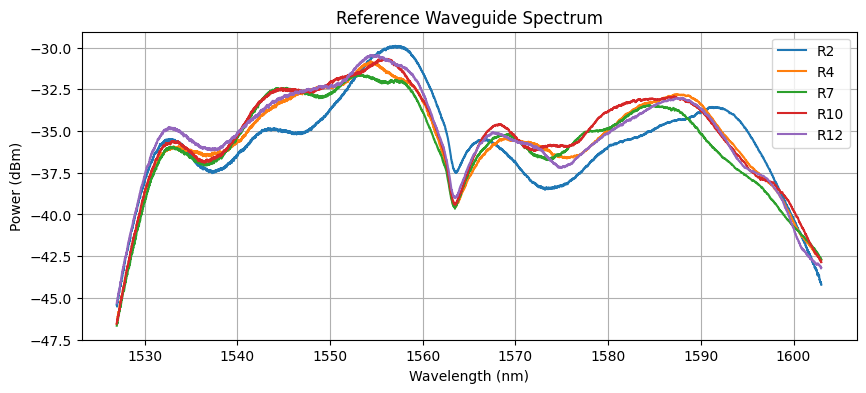

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(wavelength_wg_r2, power_wg_r2, label='R2')
plt.plot(wavelength_wg_r4, power_wg_r4, label='R4')
plt.plot(wavelength_wg_r7, power_wg_r7, label='R7')
plt.plot(wavelength_wg_r10, power_wg_r10, label='R10')
plt.plot(wavelength_wg_r12, power_wg_r12, label='R12')
plt.title("Reference Waveguide Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (dBm)")
plt.grid()
plt.legend() 
plt.show()

## U1

### Optical Spectrum

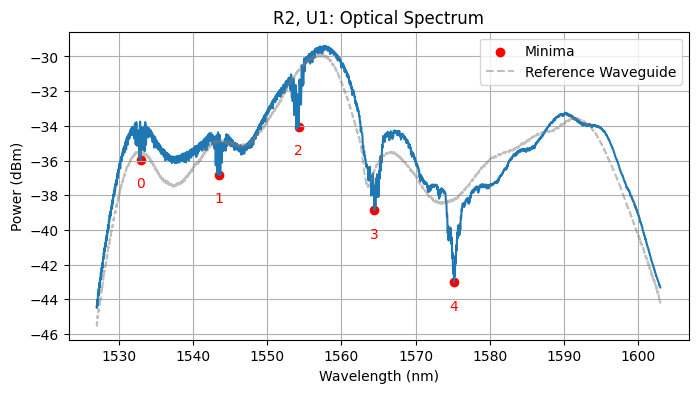

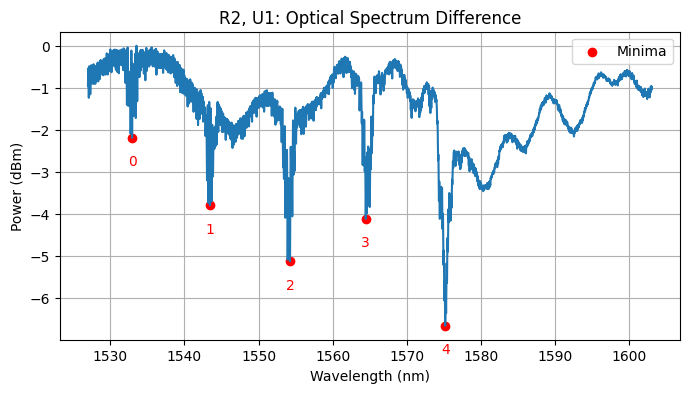

Minimums found in R2, U1 at wavelengths: [1532.948 1543.448 1554.24  1564.454 1575.168] nm


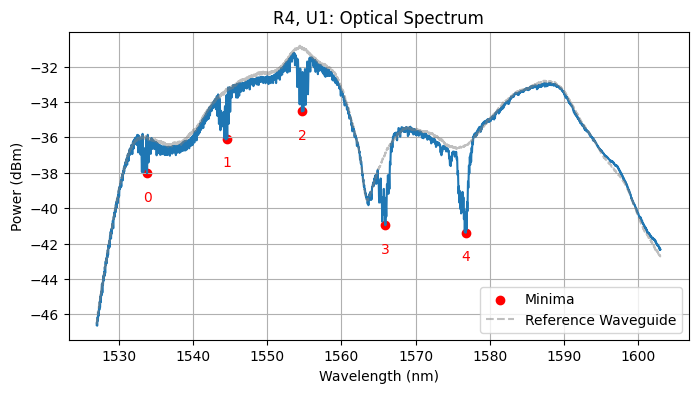

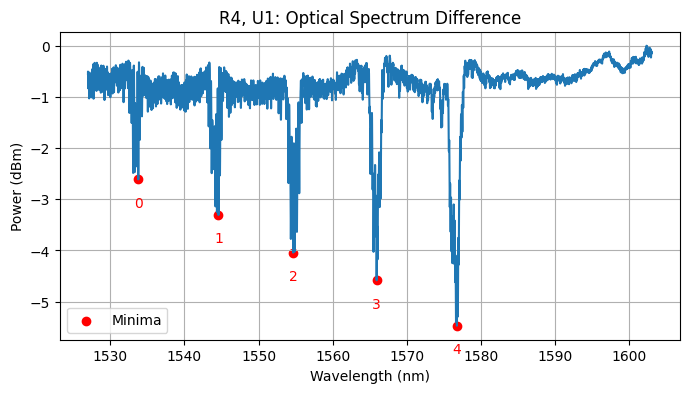

Minimums found in R4, U1 at wavelengths: [1533.784 1544.596 1554.67  1565.922 1576.746] nm


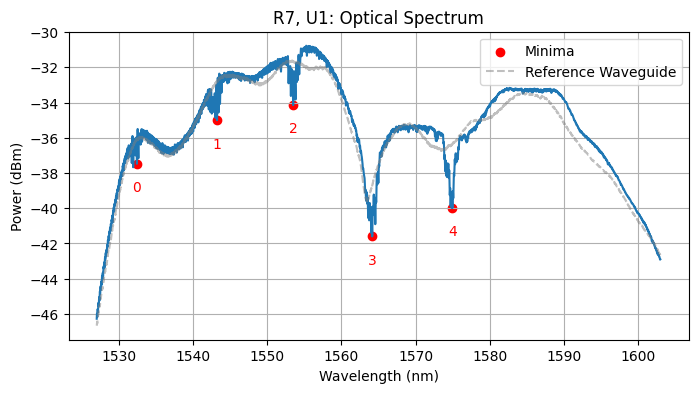

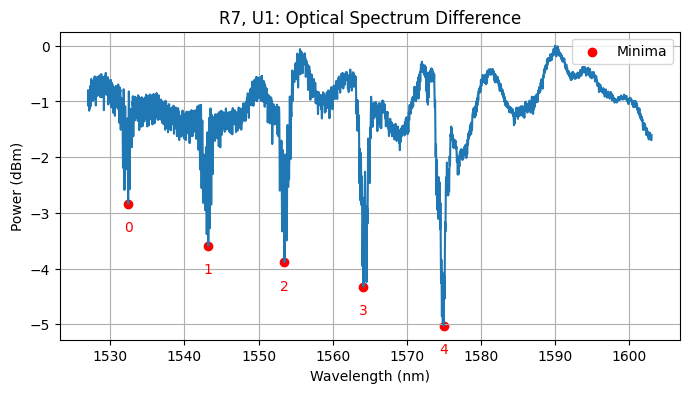

Minimums found in R7, U1 at wavelengths: [1532.418 1543.222 1553.492 1564.146 1574.96 ] nm


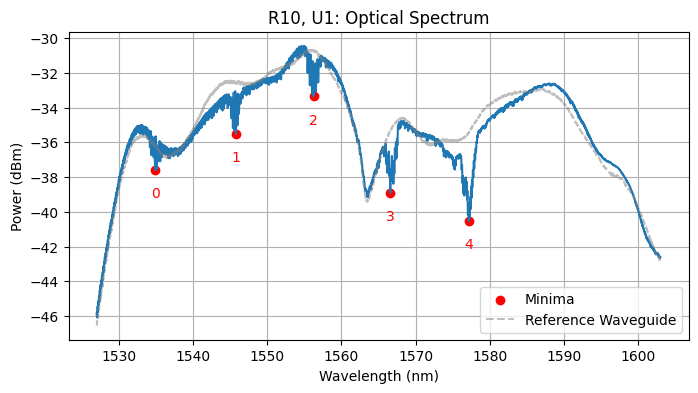

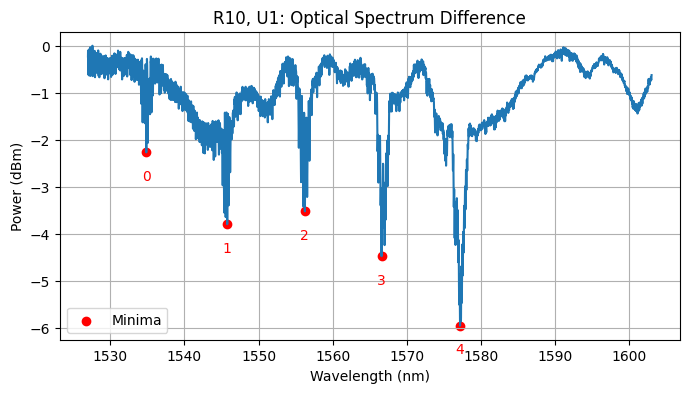

Minimums found in R10, U1 at wavelengths: [1534.864 1545.776 1556.244 1566.584 1577.17 ] nm


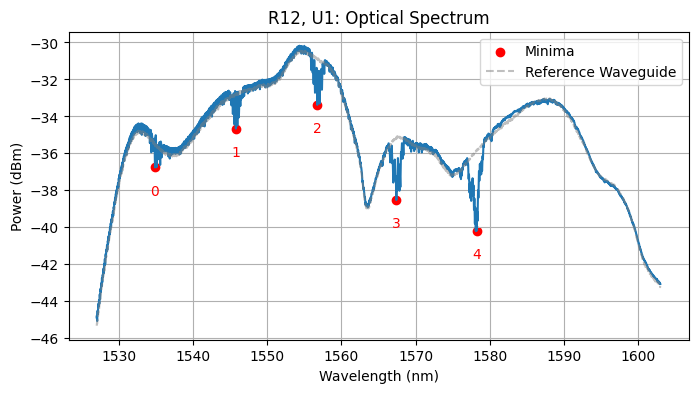

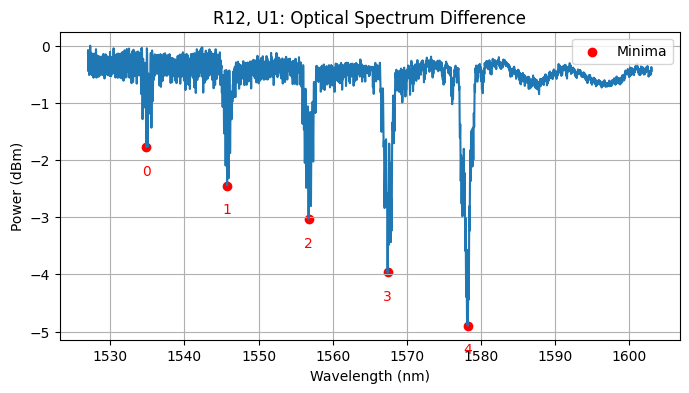

Minimums found in R12, U1 at wavelengths: [1534.856 1545.762 1556.746 1567.402 1578.226] nm


In [10]:
# Processing parameters
threshold = 1.5     # For minima detection (dB)
separation = 10      # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u1_r2 = plot_spectra(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold, separation, "R2, U1")
wl_u1_r4 = plot_spectra(wavelength_u1_r4, power_u1_r4, power_wg_r4, threshold, separation, "R4, U1")
wl_u1_r7 = plot_spectra(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, "R7, U1")
wl_u1_r10 = plot_spectra(wavelength_u1_r10, power_u1_r10, power_wg_r10, threshold, separation, "R10, U1")
wl_u1_r12 = plot_spectra(wavelength_u1_r12, power_u1_r12, power_wg_r12, threshold, separation, "R12, U1")

### Results

In [11]:
idx = 4
fc = np.round(np.arange(1.5, 0.5, -0.1), 1)

#fourier_test(power_u1_r12, wavelength_u1_r12, power_wg_r12, window_size, threshold, separation, idx, fc, "U1, R12")

In [12]:
# Processing parameters
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u1 = [0.8, 0.8, 0.8, 0.8, 0.7]       # Cutoff frequency for filtering (Hz)

#plot_reflectivity_fourier(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold, separation, window_size, "U1, R2", fc_u1, threshold_fourier)

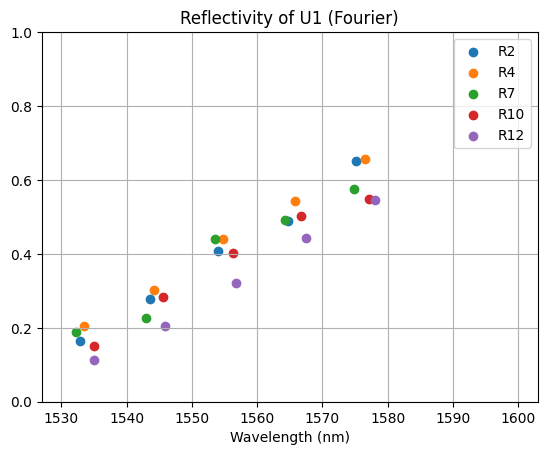

In [13]:
wl_u1_r2_fourier, R_u1_r2_fourier, BW_u1_r2_fourier = reflectivity_fourier(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r4_fourier, R_u1_r4_fourier, BW_u1_r4_fourier = reflectivity_fourier(wavelength_u1_r4, power_u1_r4, power_wg_r4, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r7_fourier, R_u1_r7_fourier, BW_u1_r7_fourier = reflectivity_fourier(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r10_fourier, R_u1_r10_fourier, BW_u1_r10_fourier = reflectivity_fourier(wavelength_u1_r10, power_u1_r10, power_wg_r10, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r12_fourier, R_u1_r12_fourier, BW_u1_r12_fourier = reflectivity_fourier(wavelength_u1_r12, power_u1_r12, power_wg_r12, threshold, separation, window_size, fc_u1, threshold_fourier)

plt.scatter(wl_u1_r2_fourier, R_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, R_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, R_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, R_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, R_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U1 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

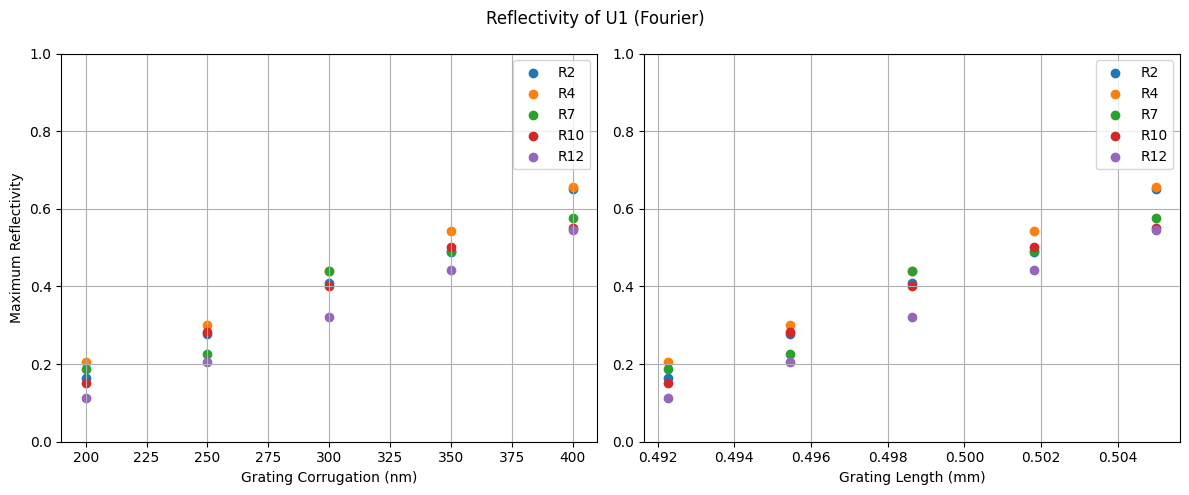

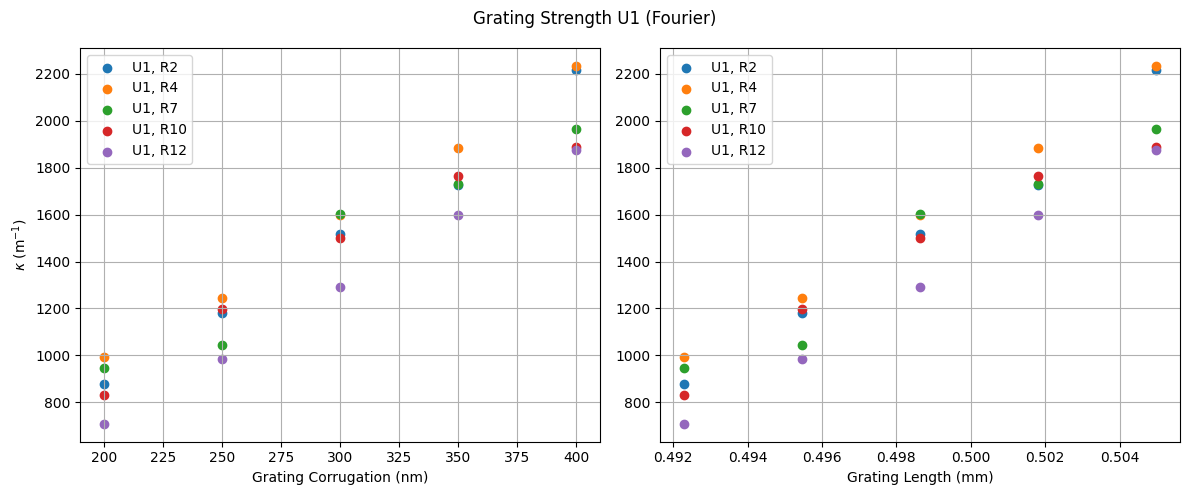

In [14]:
k_u1_r2_fourier, L_u1_r2_fourier, dW_u1_r2_fourier = grating_strength(wl_u1, wl_u1_r2_fourier, R_u1_r2_fourier, dW_u1, N_u1, n_eff)
k_u1_r4_fourier, L_u1_r4_fourier, dW_u1_r4_fourier = grating_strength(wl_u1, wl_u1_r4_fourier, R_u1_r4_fourier, dW_u1, N_u1, n_eff)
k_u1_r7_fourier, L_u1_r7_fourier, dW_u1_r7_fourier = grating_strength(wl_u1, wl_u1_r7_fourier, R_u1_r7_fourier, dW_u1, N_u1, n_eff)
k_u1_r10_fourier, L_u1_r10_fourier, dW_u1_r10_fourier = grating_strength(wl_u1, wl_u1_r10_fourier, R_u1_r10_fourier, dW_u1, N_u1, n_eff)
k_u1_r12_fourier, L_u1_r12_fourier, dW_u1_r12_fourier = grating_strength(wl_u1, wl_u1_r12_fourier, R_u1_r12_fourier, dW_u1, N_u1, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u1_r2_fourier, R_u1_r2_fourier, label = 'R2')
axs[0].scatter(dW_u1_r4_fourier, R_u1_r4_fourier, label = 'R4')
axs[0].scatter(dW_u1_r7_fourier, R_u1_r7_fourier, label = 'R7')
axs[0].scatter(dW_u1_r10_fourier, R_u1_r10_fourier, label = 'R10')
axs[0].scatter(dW_u1_r12_fourier, R_u1_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u1_r2_fourier*1e3, R_u1_r2_fourier, label = 'R2')
axs[1].scatter(L_u1_r4_fourier*1e3, R_u1_r4_fourier, label = 'R4')
axs[1].scatter(L_u1_r7_fourier*1e3, R_u1_r7_fourier, label = 'R7')
axs[1].scatter(L_u1_r10_fourier*1e3, R_u1_r10_fourier, label = 'R10')
axs[1].scatter(L_u1_r12_fourier*1e3, R_u1_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U1 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u1_r2_fourier, k_u1_r2_fourier, label = 'U1, R2')
axs[0].scatter(dW_u1_r4_fourier, k_u1_r4_fourier, label = 'U1, R4')
axs[0].scatter(dW_u1_r7_fourier, k_u1_r7_fourier, label = 'U1, R7')
axs[0].scatter(dW_u1_r10_fourier, k_u1_r10_fourier, label = 'U1, R10')
axs[0].scatter(dW_u1_r12_fourier, k_u1_r12_fourier, label = 'U1, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u1_r2_fourier*1e3, k_u1_r2_fourier, label = 'U1, R2')
axs[1].scatter(L_u1_r4_fourier*1e3, k_u1_r4_fourier, label = 'U1, R4')
axs[1].scatter(L_u1_r7_fourier*1e3, k_u1_r7_fourier, label = 'U1, R7')
axs[1].scatter(L_u1_r10_fourier*1e3, k_u1_r10_fourier, label = 'U1, R10')
axs[1].scatter(L_u1_r12_fourier*1e3, k_u1_r12_fourier, label = 'U1, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U1 (Fourier)")
plt.tight_layout()
plt.show()

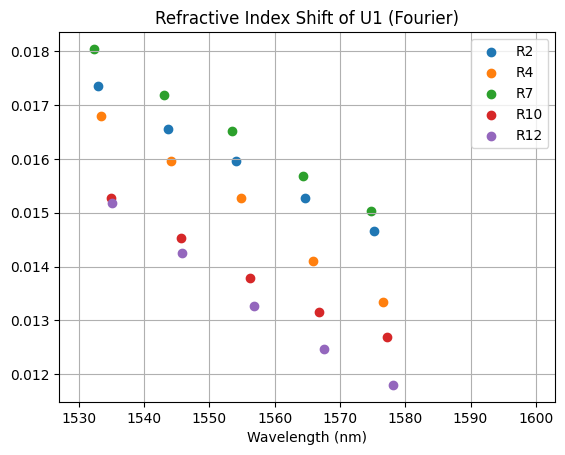

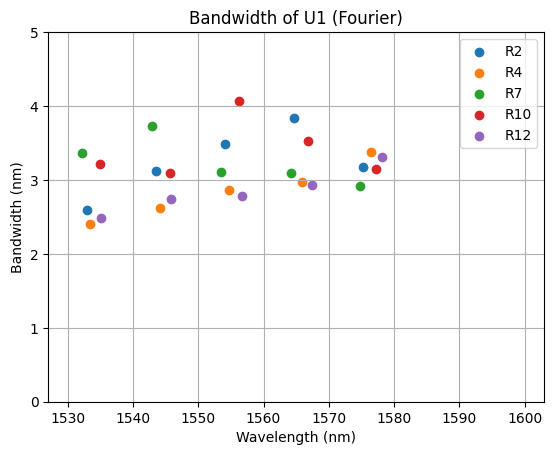

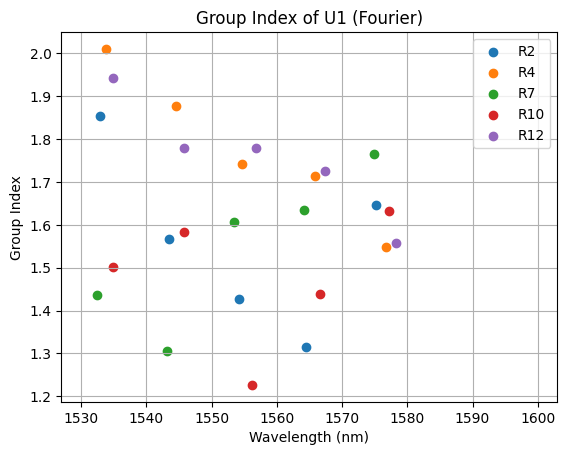

In [15]:
dwl_u1_r2_fourier, dn_u1_r2_fourier = shift_analysis(wl_u1, wl_u1_r2_fourier, n_eff)
dwl_u1_r4_fourier, dn_u1_r4_fourier = shift_analysis(wl_u1, wl_u1_r4_fourier, n_eff)
dwl_u1_r7_fourier, dn_u1_r7_fourier = shift_analysis(wl_u1, wl_u1_r7_fourier, n_eff)
dwl_u1_r10_fourier, dn_u1_r10_fourier = shift_analysis(wl_u1, wl_u1_r10_fourier, n_eff)
dwl_u1_r12_fourier, dn_u1_r12_fourier = shift_analysis(wl_u1, wl_u1_r12_fourier, n_eff)

plt.scatter(wl_u1_r2_fourier, dn_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, dn_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, dn_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, dn_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, dn_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Refractive Index Shift of U1 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()   
plt.show()

plt.scatter(wl_u1_r2_fourier, BW_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, BW_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, BW_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, BW_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, BW_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U1 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 5)
plt.grid()
plt.legend()
plt.show()

ng_u1_r2 = group_index(wl_u1_r2, BW_u1_r2_fourier, k_u1_r2_fourier, L_u1_r2_fourier)
ng_u1_r4 = group_index(wl_u1_r4, BW_u1_r4_fourier, k_u1_r4_fourier, L_u1_r4_fourier)
ng_u1_r7 = group_index(wl_u1_r7, BW_u1_r7_fourier, k_u1_r7_fourier, L_u1_r7_fourier)
ng_u1_r10 = group_index(wl_u1_r10, BW_u1_r10_fourier, k_u1_r10_fourier, L_u1_r10_fourier)
ng_u1_r12 = group_index(wl_u1_r12, BW_u1_r12_fourier, k_u1_r12_fourier, L_u1_r12_fourier)    

plt.scatter(wl_u1_r2, ng_u1_r2, label='R2')
plt.scatter(wl_u1_r4, ng_u1_r4, label='R4')
plt.scatter(wl_u1_r7, ng_u1_r7, label='R7')
plt.scatter(wl_u1_r10, ng_u1_r10, label='R10')
plt.scatter(wl_u1_r12, ng_u1_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U1 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## U2

### Optical Spectrum

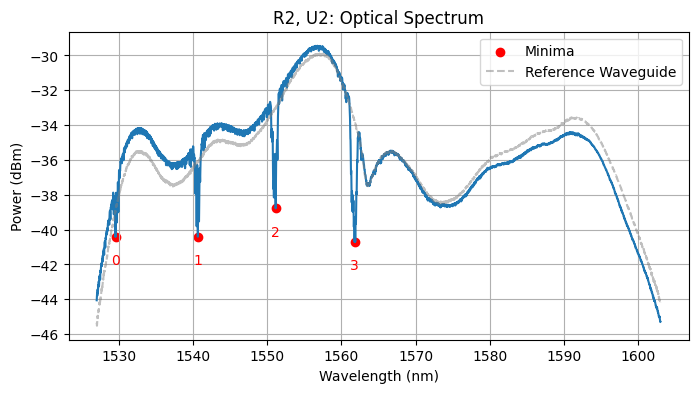

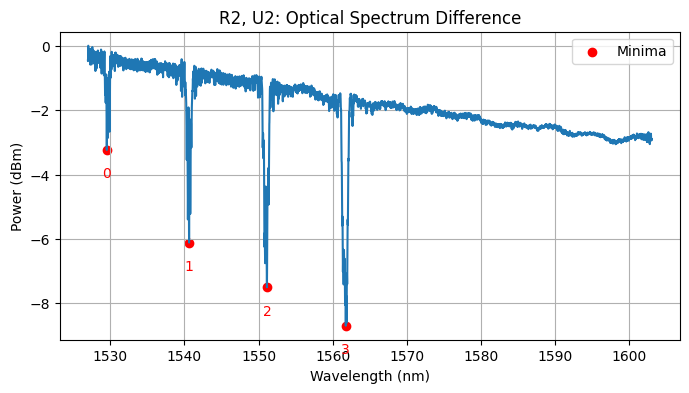

Minimums found in R2, U2 at wavelengths: [1529.538 1540.632 1551.128 1561.764] nm


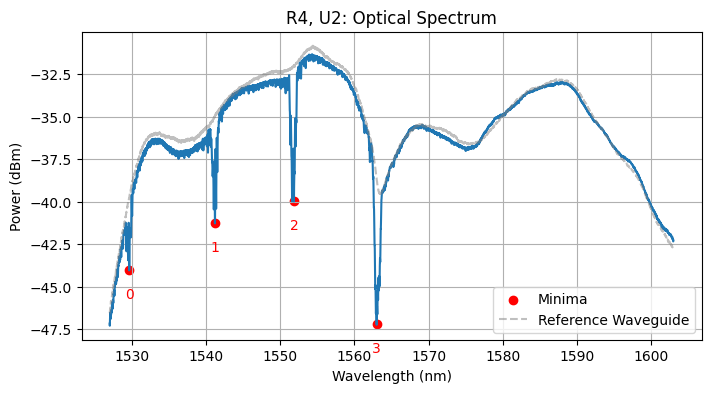

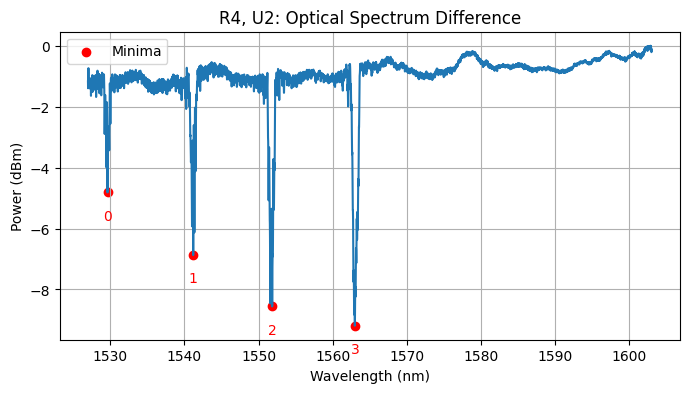

Minimums found in R4, U2 at wavelengths: [1529.636 1541.19  1551.838 1562.982] nm


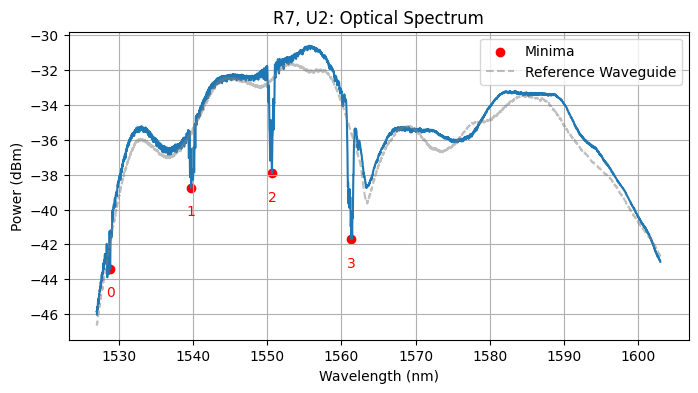

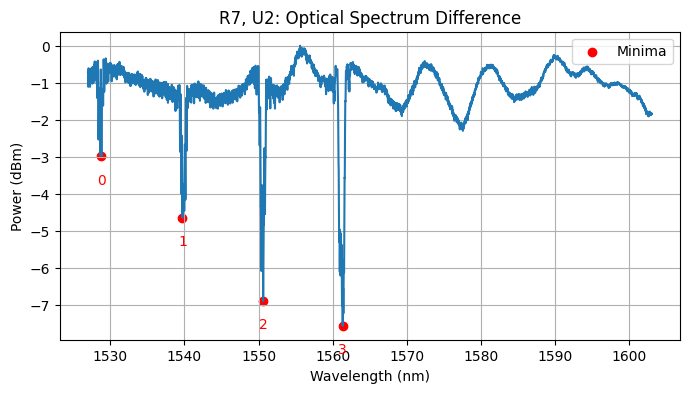

Minimums found in R7, U2 at wavelengths: [1528.81  1539.736 1550.622 1561.348] nm


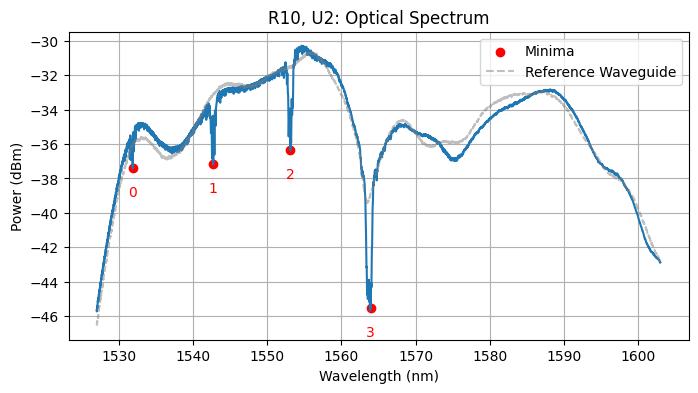

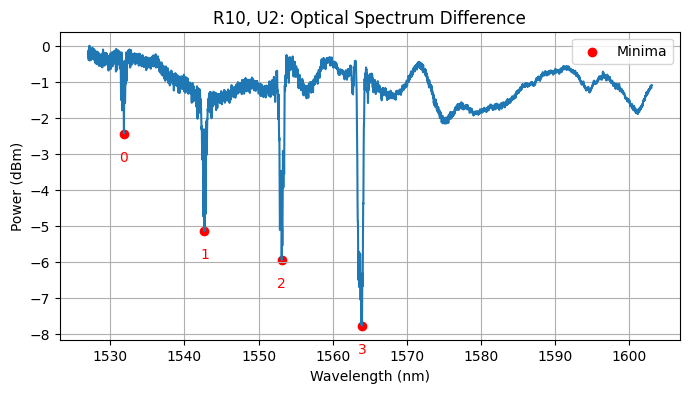

Minimums found in R10, U2 at wavelengths: [1531.848 1542.71  1553.118 1563.946] nm


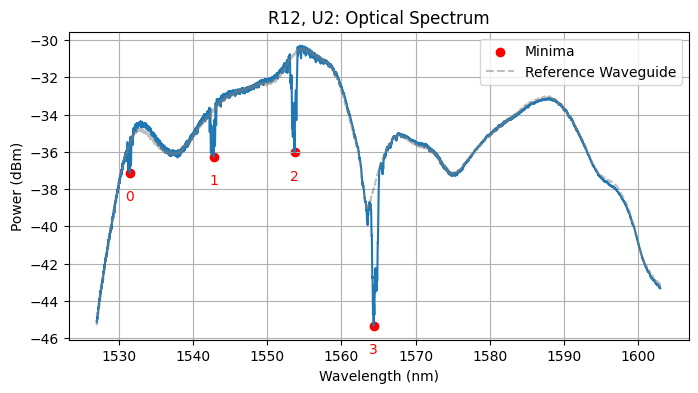

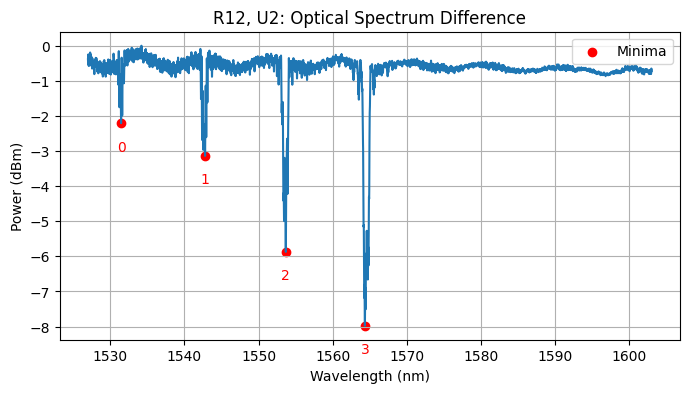

Minimums found in R12, U2 at wavelengths: [1531.464 1542.79  1553.676 1564.34 ] nm


In [16]:
# Processing parameters
threshold = 2       # For minima detection (dB)
separation = 10     # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u2_r2 = plot_spectra(wavelength_u2_r2, power_u2_r2, power_wg_r2, threshold, separation, "R2, U2")
wl_u2_r4 = plot_spectra(wavelength_u2_r4, power_u2_r4, power_wg_r4, threshold, separation, "R4, U2")
wl_u2_r7 = plot_spectra(wavelength_u2_r7, power_u2_r7, power_wg_r7, threshold, separation, "R7, U2")
wl_u2_r10 = plot_spectra(wavelength_u2_r10, power_u2_r10, power_wg_r10, threshold, separation, "R10, U2")
wl_u2_r12 = plot_spectra(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, "R12, U2")

### Results

In [17]:
idx = 3
fc = np.round(np.arange(2, 0.5, -0.1), 1)

#fourier_test(power_u2_r4, wavelength_u2_r4, power_wg_r4, window_size, threshold, separation, idx, fc, "U2, R4")

In [18]:
# Processing parameters
threshold = 2
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u2 = [1.6, 1.6, 1.5, 1.5]       # Cutoff frequency for filtering (Hz)

#plot_reflectivity_fourier(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, window_size, "U2, R12", fc_u2, threshold_fourier)

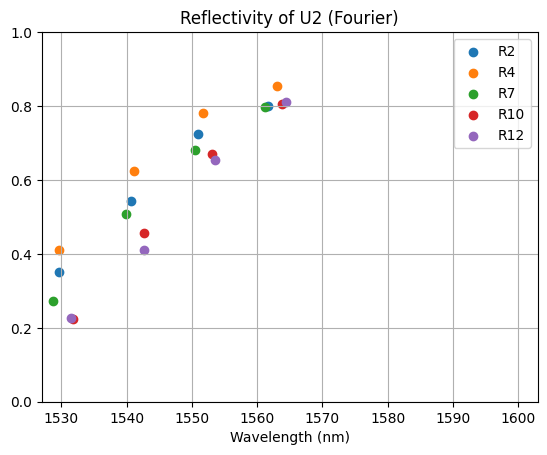

In [19]:
wl_u2_r2_fourier, R_u2_r2_fourier, BW_u2_r2_fourier = reflectivity_fourier(wavelength_u2_r2, power_u2_r2, power_wg_r2, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r4_fourier, R_u2_r4_fourier, BW_u2_r4_fourier = reflectivity_fourier(wavelength_u2_r4, power_u2_r4, power_wg_r4, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r7_fourier, R_u2_r7_fourier, BW_u2_r7_fourier = reflectivity_fourier(wavelength_u2_r7, power_u2_r7, power_wg_r7, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r10_fourier, R_u2_r10_fourier, BW_u2_r10_fourier = reflectivity_fourier(wavelength_u2_r10, power_u2_r10, power_wg_r10, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r12_fourier, R_u2_r12_fourier, BW_u2_r12_fourier = reflectivity_fourier(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, window_size, fc_u2, threshold_fourier)

plt.scatter(wl_u2_r2_fourier, R_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, R_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, R_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, R_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, R_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U2 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

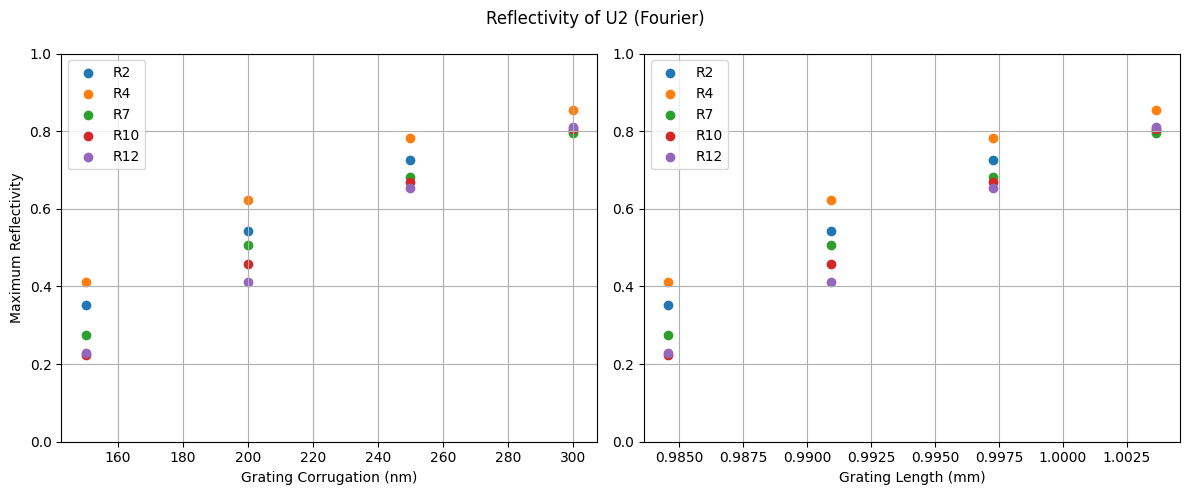

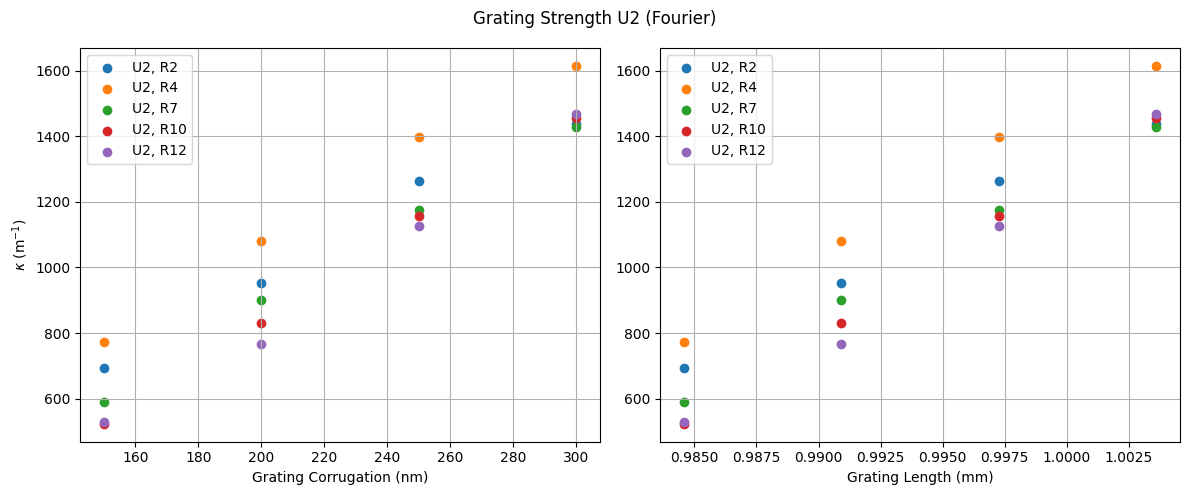

In [20]:
k_u2_r2_fourier, L_u2_r2_fourier, dW_u2_r2_fourier = grating_strength(wl_u2, wl_u2_r2_fourier, R_u2_r2_fourier, dW_u2, N_u2, n_eff)
k_u2_r4_fourier, L_u2_r4_fourier, dW_u2_r4_fourier = grating_strength(wl_u2, wl_u2_r4_fourier, R_u2_r4_fourier, dW_u2, N_u2, n_eff)
k_u2_r7_fourier, L_u2_r7_fourier, dW_u2_r7_fourier = grating_strength(wl_u2, wl_u2_r7_fourier, R_u2_r7_fourier, dW_u2, N_u2, n_eff)
k_u2_r10_fourier, L_u2_r10_fourier, dW_u2_r10_fourier = grating_strength(wl_u2, wl_u2_r10_fourier, R_u2_r10_fourier, dW_u2, N_u2, n_eff)
k_u2_r12_fourier, L_u2_r12_fourier, dW_u2_r12_fourier = grating_strength(wl_u2, wl_u2_r12_fourier, R_u2_r12_fourier, dW_u2, N_u2, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u2_r2_fourier, R_u2_r2_fourier, label = 'R2')
axs[0].scatter(dW_u2_r4_fourier, R_u2_r4_fourier, label = 'R4')
axs[0].scatter(dW_u2_r7_fourier, R_u2_r7_fourier, label = 'R7')
axs[0].scatter(dW_u2_r10_fourier, R_u2_r10_fourier, label = 'R10')
axs[0].scatter(dW_u2_r12_fourier, R_u2_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u2_r2_fourier*1e3, R_u2_r2_fourier, label = 'R2')
axs[1].scatter(L_u2_r4_fourier*1e3, R_u2_r4_fourier, label = 'R4')
axs[1].scatter(L_u2_r7_fourier*1e3, R_u2_r7_fourier, label = 'R7')
axs[1].scatter(L_u2_r10_fourier*1e3, R_u2_r10_fourier, label = 'R10')
axs[1].scatter(L_u2_r12_fourier*1e3, R_u2_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U2 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u2_r2_fourier, k_u2_r2_fourier, label = 'U2, R2')
axs[0].scatter(dW_u2_r4_fourier, k_u2_r4_fourier, label = 'U2, R4')
axs[0].scatter(dW_u2_r7_fourier, k_u2_r7_fourier, label = 'U2, R7')
axs[0].scatter(dW_u2_r10_fourier, k_u2_r10_fourier, label = 'U2, R10')
axs[0].scatter(dW_u2_r12_fourier, k_u2_r12_fourier, label = 'U2, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u2_r2_fourier*1e3, k_u2_r2_fourier, label = 'U2, R2')
axs[1].scatter(L_u2_r4_fourier*1e3, k_u2_r4_fourier, label = 'U2, R4')
axs[1].scatter(L_u2_r7_fourier*1e3, k_u2_r7_fourier, label = 'U2, R7')
axs[1].scatter(L_u2_r10_fourier*1e3, k_u2_r10_fourier, label = 'U2, R10')
axs[1].scatter(L_u2_r12_fourier*1e3, k_u2_r12_fourier, label = 'U2, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U2 (Fourier)")
plt.tight_layout()
plt.show()

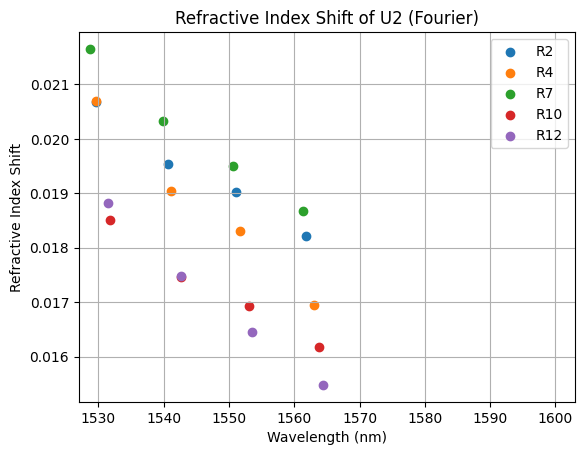

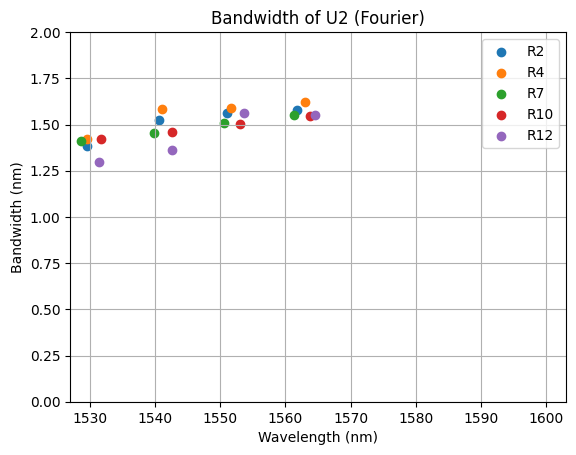

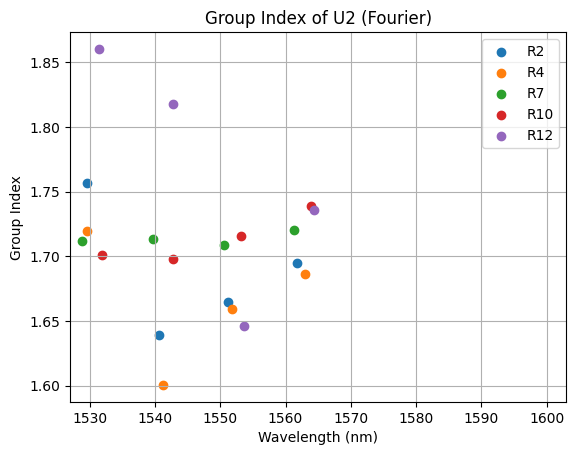

In [21]:
dwl_u2_r2_fourier, dn_u2_r2_fourier = shift_analysis(wl_u2, wl_u2_r2_fourier, n_eff)
dwl_u2_r4_fourier, dn_u2_r4_fourier = shift_analysis(wl_u2, wl_u2_r4_fourier, n_eff)
dwl_u2_r7_fourier, dn_u2_r7_fourier = shift_analysis(wl_u2, wl_u2_r7_fourier, n_eff)
dwl_u2_r10_fourier, dn_u2_r10_fourier = shift_analysis(wl_u2, wl_u2_r10_fourier, n_eff)
dwl_u2_r12_fourier, dn_u2_r12_fourier = shift_analysis(wl_u2, wl_u2_r12_fourier, n_eff)

plt.scatter(wl_u2_r2_fourier, dn_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, dn_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, dn_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, dn_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, dn_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index Shift")
plt.title("Refractive Index Shift of U2 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()  
plt.show()

plt.scatter(wl_u2_r2_fourier, BW_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, BW_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, BW_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, BW_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, BW_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U2 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()

ng_u2_r2 = group_index(wl_u2_r2, BW_u2_r2_fourier, k_u2_r2_fourier, L_u2_r2_fourier)
ng_u2_r4 = group_index(wl_u2_r4, BW_u2_r4_fourier, k_u2_r4_fourier, L_u2_r4_fourier)
ng_u2_r7 = group_index(wl_u2_r7, BW_u2_r7_fourier, k_u2_r7_fourier, L_u2_r7_fourier)
ng_u2_r10 = group_index(wl_u2_r10, BW_u2_r10_fourier, k_u2_r10_fourier, L_u2_r10_fourier)
ng_u2_r12 = group_index(wl_u2_r12, BW_u2_r12_fourier, k_u2_r12_fourier, L_u2_r12_fourier)    

plt.scatter(wl_u2_r2, ng_u2_r2, label='R2')
plt.scatter(wl_u2_r4, ng_u2_r4, label='R4')
plt.scatter(wl_u2_r7, ng_u2_r7, label='R7')
plt.scatter(wl_u2_r10, ng_u2_r10, label='R10')
plt.scatter(wl_u2_r12, ng_u2_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U2 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## U3

### Optical Spectrum

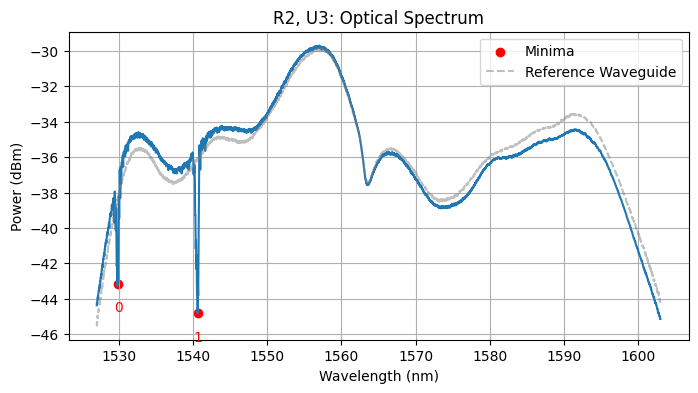

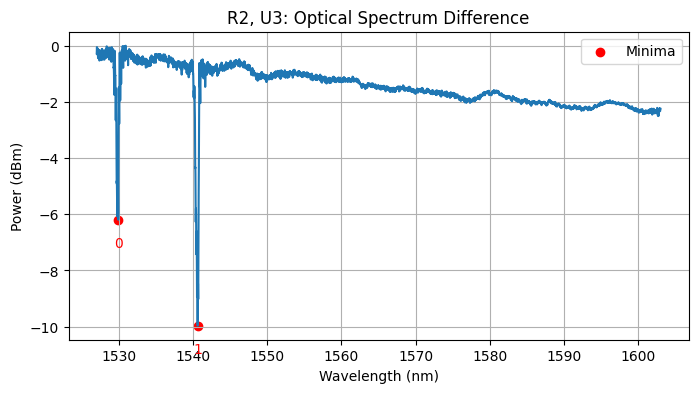

Minimums found in R2, U3 at wavelengths: [1529.898 1540.608] nm


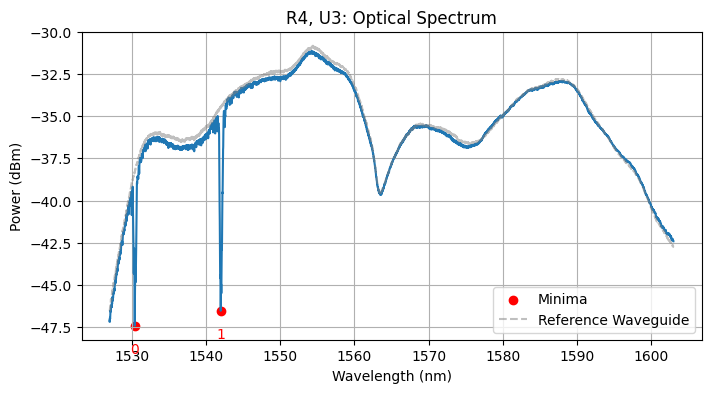

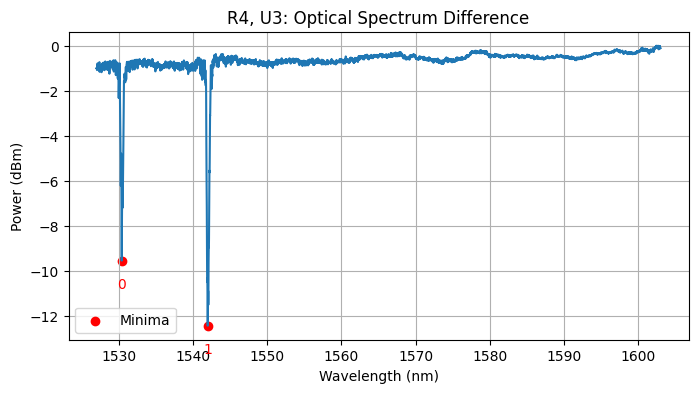

Minimums found in R4, U3 at wavelengths: [1530.372 1541.97 ] nm


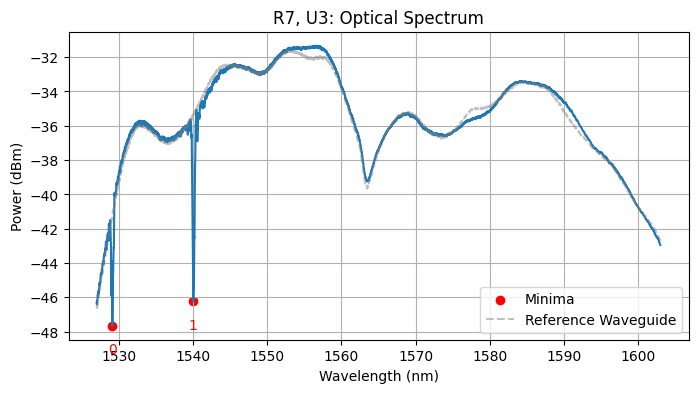

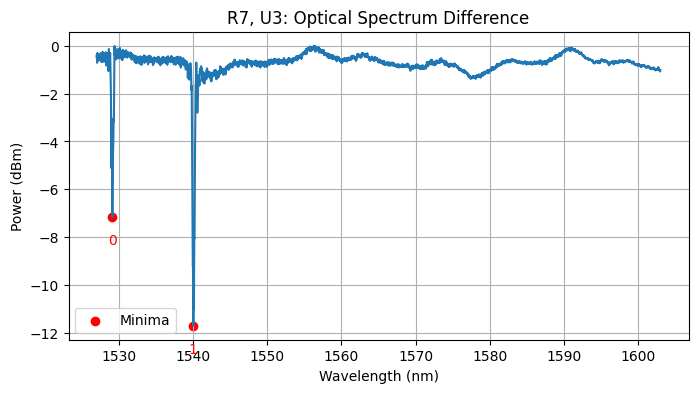

Minimums found in R7, U3 at wavelengths: [1529.108 1540.026] nm


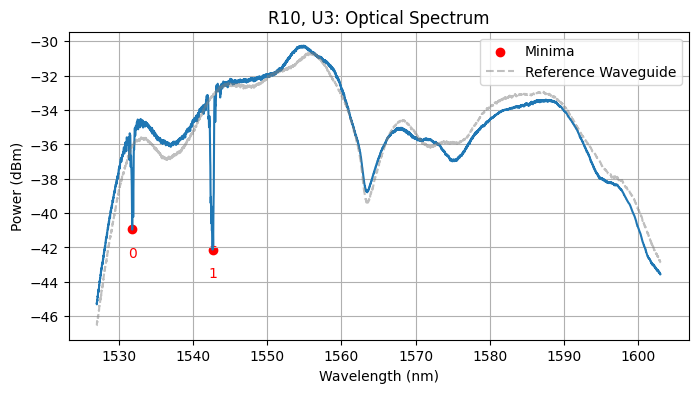

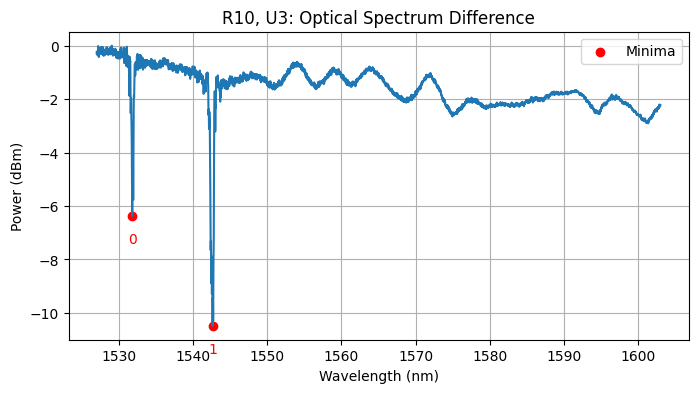

Minimums found in R10, U3 at wavelengths: [1531.788 1542.622] nm


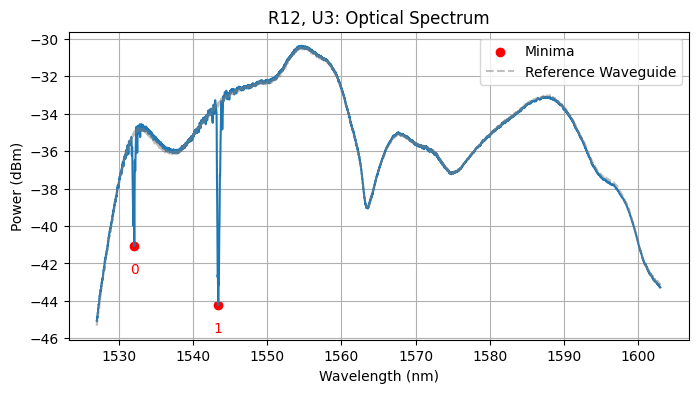

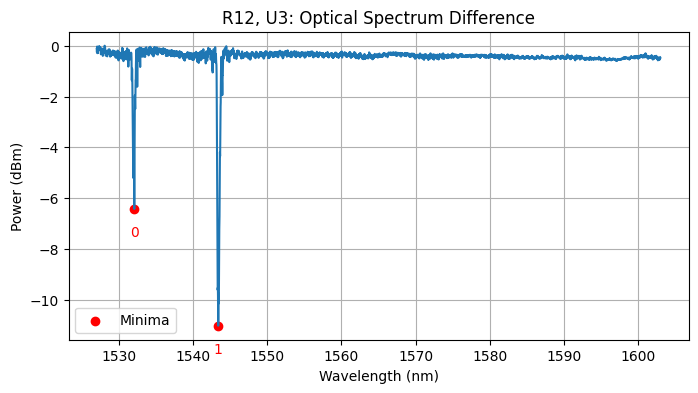

Minimums found in R12, U3 at wavelengths: [1532.064 1543.388] nm


In [22]:
# Processing parameters
threshold = 2       # For minima detection (dB)
separation = 10     # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u3_r2 = plot_spectra(wavelength_u3_r2, power_u3_r2, power_wg_r2, threshold, separation, "R2, U3")
wl_u3_r4 = plot_spectra(wavelength_u3_r4, power_u3_r4, power_wg_r4, threshold, separation, "R4, U3")
wl_u3_r7 = plot_spectra(wavelength_u3_r7, power_u3_r7, power_wg_r7, threshold, separation, "R7, U3")
wl_u3_r10 = plot_spectra(wavelength_u3_r10, power_u3_r10, power_wg_r10, threshold, separation, "R10, U3")
wl_u3_r12 = plot_spectra(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, "R12, U3")

### Results

In [23]:
idx = 1
fc = np.round(np.arange(2.5, 1.5, -0.1), 1)

#fourier_test(power_u3_r10, wavelength_u3_r10, power_wg_r10, window_size, threshold, separation, idx, fc, "U3, R10")

In [24]:
# Processing parameters
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u3 = [2, 1.7]                   # Cutoff frequency for filtering (Hz)
fc_u3_r4 = [2, 1.6]                      

#plot_reflectivity_fourier(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, window_size, "U3, R12", fc, threshold_fourier)

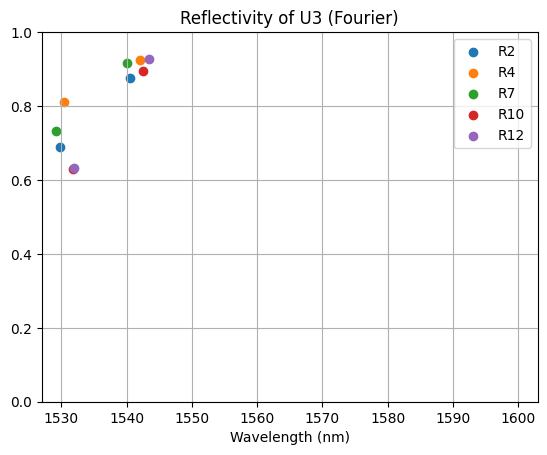

In [25]:
wl_u3_r2_fourier, R_u3_r2_fourier, BW_u3_r2_fourier = reflectivity_fourier(wavelength_u3_r2, power_u3_r2, power_wg_r2, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r4_fourier, R_u3_r4_fourier, BW_u3_r4_fourier = reflectivity_fourier(wavelength_u3_r4, power_u3_r4, power_wg_r4, threshold, separation, window_size, fc_u3_r4, threshold_fourier)
wl_u3_r7_fourier, R_u3_r7_fourier, BW_u3_r7_fourier = reflectivity_fourier(wavelength_u3_r7, power_u3_r7, power_wg_r7, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r10_fourier, R_u3_r10_fourier, BW_u3_r10_fourier = reflectivity_fourier(wavelength_u3_r10, power_u3_r10, power_wg_r10, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r12_fourier, R_u3_r12_fourier, BW_u3_r12_fourier = reflectivity_fourier(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, window_size, fc_u3, threshold_fourier)

plt.scatter(wl_u3_r2_fourier, R_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, R_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, R_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, R_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, R_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U3 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

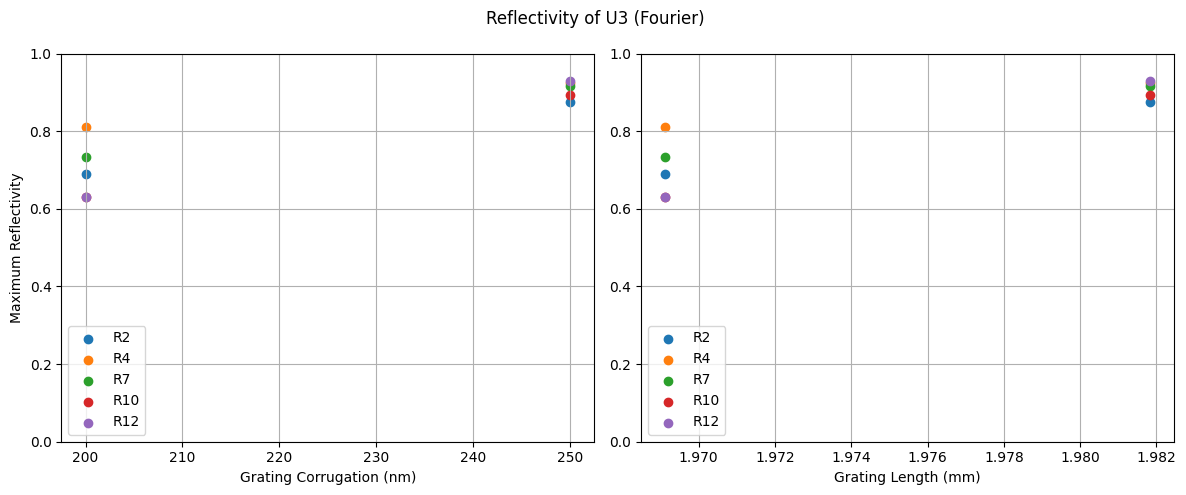

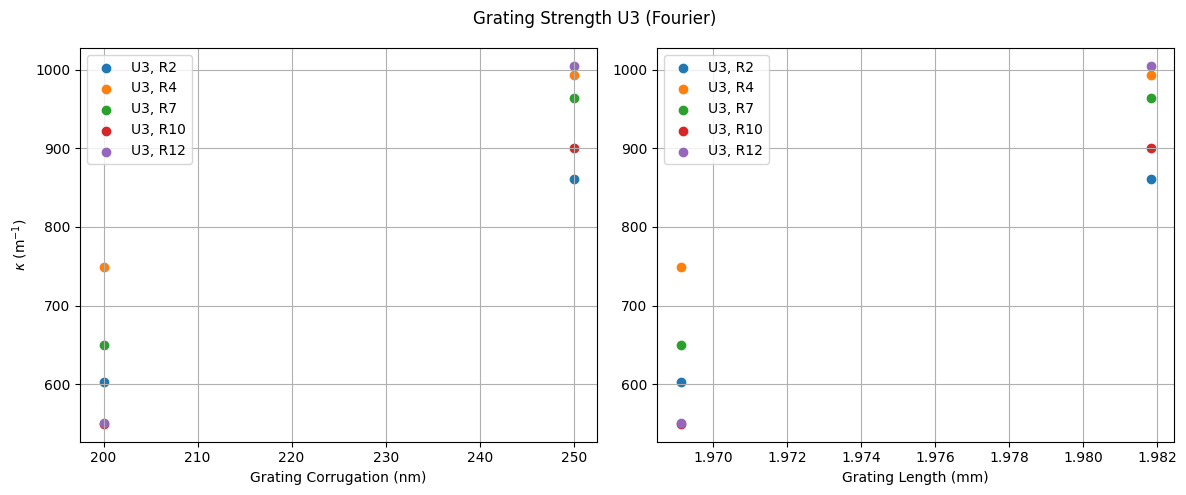

In [26]:
k_u3_r2_fourier, L_u3_r2_fourier, dW_u3_r2_fourier = grating_strength(wl_u3, wl_u3_r2_fourier, R_u3_r2_fourier, dW_u3, N_u3, n_eff)
k_u3_r4_fourier, L_u3_r4_fourier, dW_u3_r4_fourier = grating_strength(wl_u3, wl_u3_r4_fourier, R_u3_r4_fourier, dW_u3, N_u3, n_eff)
k_u3_r7_fourier, L_u3_r7_fourier, dW_u3_r7_fourier = grating_strength(wl_u3, wl_u3_r7_fourier, R_u3_r7_fourier, dW_u3, N_u3, n_eff)
k_u3_r10_fourier, L_u3_r10_fourier, dW_u3_r10_fourier = grating_strength(wl_u3, wl_u3_r10_fourier, R_u3_r10_fourier, dW_u3, N_u3, n_eff)
k_u3_r12_fourier, L_u3_r12_fourier, dW_u3_r12_fourier = grating_strength(wl_u3, wl_u3_r12_fourier, R_u3_r12_fourier, dW_u3, N_u3, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u3_r2_fourier, R_u3_r2_fourier, label = 'R2')
axs[0].scatter(dW_u3_r4_fourier, R_u3_r4_fourier, label = 'R4')
axs[0].scatter(dW_u3_r7_fourier, R_u3_r7_fourier, label = 'R7')
axs[0].scatter(dW_u3_r10_fourier, R_u3_r10_fourier, label = 'R10')
axs[0].scatter(dW_u3_r12_fourier, R_u3_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u3_r2_fourier*1e3, R_u3_r2_fourier, label = 'R2')
axs[1].scatter(L_u3_r4_fourier*1e3, R_u3_r4_fourier, label = 'R4')
axs[1].scatter(L_u3_r7_fourier*1e3, R_u3_r7_fourier, label = 'R7')
axs[1].scatter(L_u3_r10_fourier*1e3, R_u3_r10_fourier, label = 'R10')
axs[1].scatter(L_u3_r12_fourier*1e3, R_u3_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U3 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u3_r2_fourier, k_u3_r2_fourier, label = 'U3, R2')
axs[0].scatter(dW_u3_r4_fourier, k_u3_r4_fourier, label = 'U3, R4')
axs[0].scatter(dW_u3_r7_fourier, k_u3_r7_fourier, label = 'U3, R7')
axs[0].scatter(dW_u3_r10_fourier, k_u3_r10_fourier, label = 'U3, R10')
axs[0].scatter(dW_u3_r12_fourier, k_u3_r12_fourier, label = 'U3, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u3_r2_fourier*1e3, k_u3_r2_fourier, label = 'U3, R2')
axs[1].scatter(L_u3_r4_fourier*1e3, k_u3_r4_fourier, label = 'U3, R4')
axs[1].scatter(L_u3_r7_fourier*1e3, k_u3_r7_fourier, label = 'U3, R7')
axs[1].scatter(L_u3_r10_fourier*1e3, k_u3_r10_fourier, label = 'U3, R10')
axs[1].scatter(L_u3_r12_fourier*1e3, k_u3_r12_fourier, label = 'U3, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U3 (Fourier)")
plt.tight_layout()
plt.show()

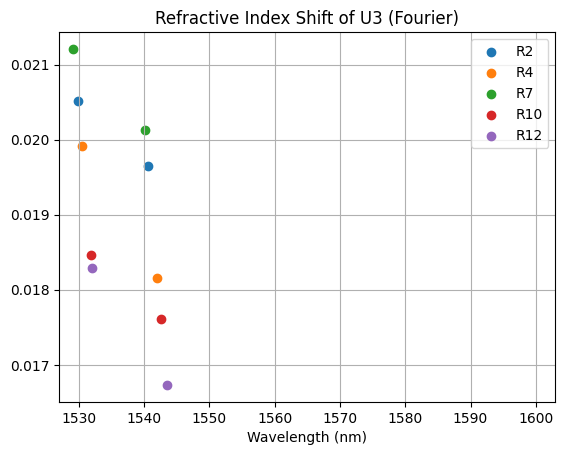

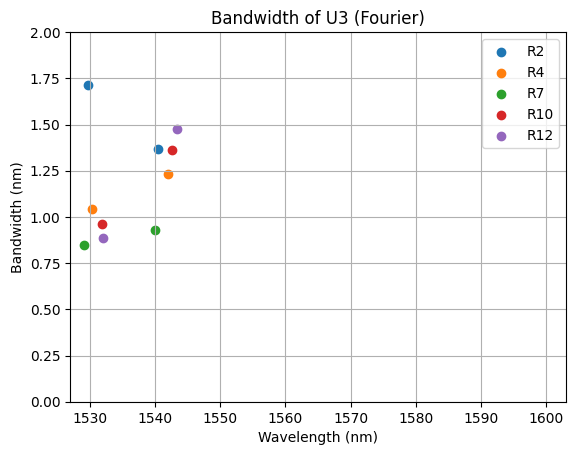

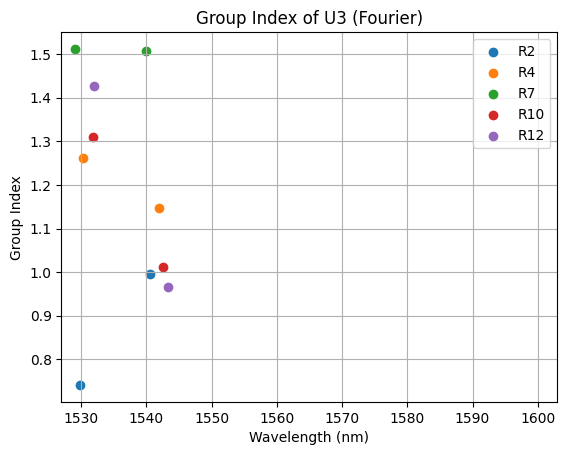

In [27]:
dwl_u3_r2_fourier, dn_u3_r2_fourier = shift_analysis(wl_u3, wl_u3_r2_fourier, n_eff)
dwl_u3_r4_fourier, dn_u3_r4_fourier = shift_analysis(wl_u3, wl_u3_r4_fourier, n_eff)
dwl_u3_r7_fourier, dn_u3_r7_fourier = shift_analysis(wl_u3, wl_u3_r7_fourier, n_eff)
dwl_u3_r10_fourier, dn_u3_r10_fourier = shift_analysis(wl_u3, wl_u3_r10_fourier, n_eff)
dwl_u3_r12_fourier, dn_u3_r12_fourier = shift_analysis(wl_u3, wl_u3_r12_fourier, n_eff)

plt.scatter(wl_u3_r2_fourier, dn_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, dn_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, dn_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, dn_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, dn_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Refractive Index Shift of U3 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()   
plt.show()

plt.scatter(wl_u3_r2_fourier, BW_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, BW_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, BW_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, BW_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, BW_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U3 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()

ng_u3_r2 = group_index(wl_u3_r2, BW_u3_r2_fourier, k_u3_r2_fourier, L_u3_r2_fourier)
ng_u3_r4 = group_index(wl_u3_r4, BW_u3_r4_fourier, k_u3_r4_fourier, L_u3_r4_fourier)
ng_u3_r7 = group_index(wl_u3_r7, BW_u3_r7_fourier, k_u3_r7_fourier, L_u3_r7_fourier)
ng_u3_r10 = group_index(wl_u3_r10, BW_u3_r10_fourier, k_u3_r10_fourier, L_u3_r10_fourier)
ng_u3_r12 = group_index(wl_u3_r12, BW_u3_r12_fourier, k_u3_r12_fourier, L_u3_r12_fourier)    

plt.scatter(wl_u3_r2, ng_u3_r2, label='R2')
plt.scatter(wl_u3_r4, ng_u3_r4, label='R4')
plt.scatter(wl_u3_r7, ng_u3_r7, label='R7')
plt.scatter(wl_u3_r10, ng_u3_r10, label='R10')
plt.scatter(wl_u3_r12, ng_u3_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U3 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## Grating Strength Fit

### Auxiliar Function

In [ ]:
def reflectivity_corrugation_fourier(w):
    buff_R = []
    buff_L = []
    mean_R = []
    mean_L = []

    if w < np.min([np.min(dW_u1_r2_fourier), np.min(dW_u2_r2_fourier), np.min(dW_u3_r2_fourier)]) or w > np.max([np.max(dW_u1_r2_fourier), np.max(dW_u2_r2_fourier), np.max(dW_u3_r2_fourier)]):
        print(f'No data')
        return None

    if w<min(dW_u1_r2_fourier) or w>max(dW_u1_r2_fourier):
        print(f'No data for U1 for grating corrugation of {w} nm')

    if w<min(dW_u2_r2_fourier) or w>max(dW_u2_r2_fourier):
        print(f'No data for U2 for grating corrugation of {w} nm')

    if w<min(dW_u3_r2_fourier) or w>max(dW_u3_r2_fourier):
        print(f'No data for U3 for grating corrugation of {w} nm')
    

    for i in range(len(dW_u1_r2_fourier)):
        if dW_u1_r2_fourier[i] == w:
            buff_R.append(R_u1_r2_fourier[i]); buff_R.append(R_u1_r4_fourier[i]); buff_R.append(R_u1_r7_fourier[i]); buff_R.append(R_u1_r10_fourier[i]); buff_R.append(R_u1_r12_fourier[i])
            mean_R.append(np.mean([R_u1_r2_fourier[i], R_u1_r4_fourier[i], R_u1_r7_fourier[i], R_u1_r10_fourier[i], R_u1_r12_fourier[i]]))

            buff_L.append(L_u1_r2_fourier[i]); buff_L.append(L_u1_r4_fourier[i]); buff_L.append(L_u1_r7_fourier[i]); buff_L.append(L_u1_r10_fourier[i]); buff_L.append(L_u1_r12_fourier[i])
            mean_L.append(np.mean([L_u1_r2_fourier[i], L_u1_r4_fourier[i], L_u1_r7_fourier[i], L_u1_r10_fourier[i], L_u1_r12_fourier[i]]))

    for i in range(len(dW_u2_r2_fourier)):
        if dW_u2_r2_fourier[i] == w:
            buff_R.append(R_u2_r2_fourier[i]); buff_R.append(R_u2_r4_fourier[i]); buff_R.append(R_u2_r7_fourier[i]); buff_R.append(R_u2_r10_fourier[i]); buff_R.append(R_u2_r12_fourier[i])
            mean_R.append(np.mean([R_u2_r2_fourier[i], R_u2_r4_fourier[i], R_u2_r7_fourier[i], R_u2_r10_fourier[i], R_u2_r12_fourier[i]]))

            buff_L.append(L_u2_r2_fourier[i]); buff_L.append(L_u2_r4_fourier[i]); buff_L.append(L_u2_r7_fourier[i]); buff_L.append(L_u2_r10_fourier[i]); buff_L.append(L_u2_r12_fourier[i])
            mean_L.append(np.mean([L_u2_r2_fourier[i], L_u2_r4_fourier[i], L_u2_r7_fourier[i], L_u2_r10_fourier[i], L_u2_r12_fourier[i]]))

    for i in range(len(dW_u3_r2_fourier)):
        if dW_u3_r2_fourier[i] == w:
            buff_R.append(R_u3_r2_fourier[i]); buff_R.append(R_u3_r4_fourier[i]); buff_R.append(R_u3_r7_fourier[i]); buff_R.append(R_u3_r10_fourier[i]); buff_R.append(R_u3_r12_fourier[i])
            mean_R.append(np.mean([R_u3_r2_fourier[i], R_u3_r4_fourier[i], R_u3_r7_fourier[i], R_u3_r10_fourier[i], R_u3_r12_fourier[i]]))

            buff_L.append(L_u3_r2_fourier[i]); buff_L.append(L_u3_r4_fourier[i]); buff_L.append(L_u3_r7_fourier[i]); buff_L.append(L_u3_r10_fourier[i]); buff_L.append(L_u3_r12_fourier[i])
            mean_L.append(np.mean([L_u3_r2_fourier[i], L_u3_r4_fourier[i], L_u3_r7_fourier[i], L_u3_r10_fourier[i], L_u3_r12_fourier[i]]))

    plt.scatter(np.array(buff_L)*1e3, np.array(buff_R), label='Data')
    plt.scatter(np.array(mean_L)*1e3, np.array(mean_R), label='Mean', color='r')
    plt.title(f'Maximum Reflectivity (Fourier) for Corrugation {w} nm')

    x = np.linspace(0, 1.5*np.max(buff_L), 100)
    popt, pcov = curve_fit(reflectivity_model, mean_L, mean_R)
    plt.plot(x*1e3, reflectivity_model(x, *popt), label=r'$tanh^2(\kappa L)$', color='orange')

    plt.annotate(rf'$\kappa$={popt[0]:.2f}, Cov.={pcov[0,0]:.2f}', xy=[0.95,0.05], xycoords = 'axes fraction', ha = 'right', va = 'bottom', fontsize=11)
    plt.legend()
    plt.xlabel('Grating Length (mm)')
    plt.ylabel('Reflectivity')
    plt.grid()
    plt.show()

### Results

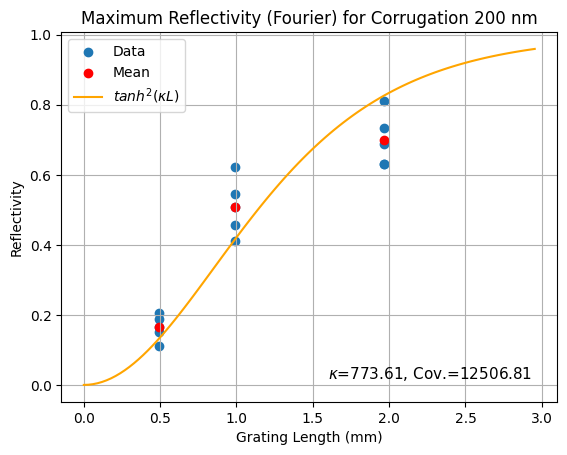

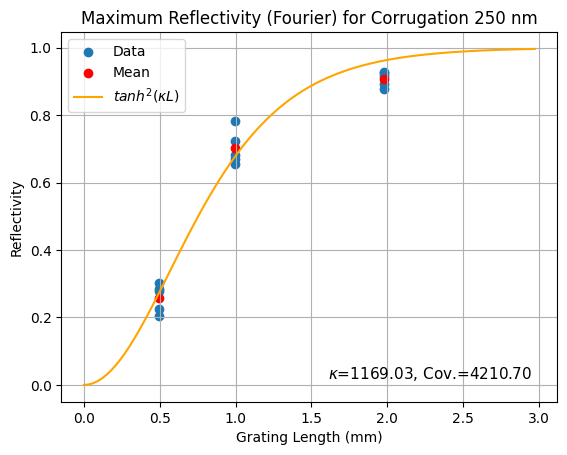

No data for U3 for grating corrugation of 300 nm


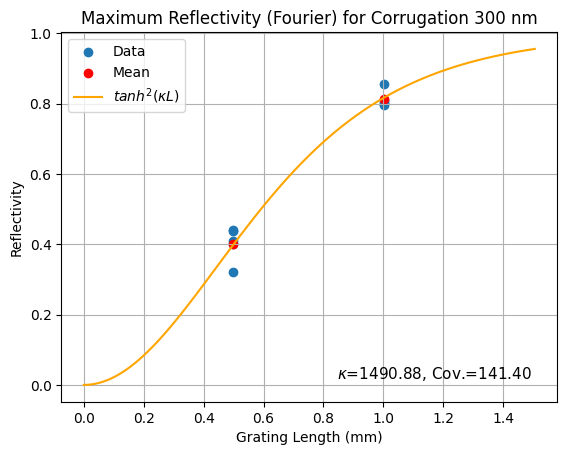

In [29]:
reflectivity_corrugation_fourier(200)
reflectivity_corrugation_fourier(250)
reflectivity_corrugation_fourier(300)

# YOKO

## Initialization

In [30]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\wg.txt" 
wavelength_wg_r2, power_wg_r2 = open_file(file_path)
wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\wg.txt" 
wavelength_wg_r4, power_wg_r4 = open_file(file_path)
wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\wg.txt" 
wavelength_wg_r7, power_wg_r7 = open_file(file_path)
wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\wg.txt" 
wavelength_wg_r10, power_wg_r10 = open_file(file_path)
wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\wg.txt" 
wavelength_wg_r12, power_wg_r12 = open_file(file_path)
wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

In [31]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u1.txt" 
wavelength_u1_r2, power_u1_r2 = open_file(file_path)
wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u1.txt" 
wavelength_u1_r4, power_u1_r4 = open_file(file_path)
wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u1.txt" 
wavelength_u1_r7, power_u1_r7 = open_file(file_path)
wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u1.txt" 
wavelength_u1_r10, power_u1_r10 = open_file(file_path)
wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u1.txt" # Read mode so \u... is not interpreted as unicode
wavelength_u1_r12, power_u1_r12 = open_file(file_path)
wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

In [32]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u2.txt" 
wavelength_u2_r2, power_u2_r2 = open_file(file_path)
wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u2.txt" 
wavelength_u2_r4, power_u2_r4 = open_file(file_path)
wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u2.txt" 
wavelength_u2_r7, power_u2_r7 = open_file(file_path)
wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u2.txt" 
wavelength_u2_r10, power_u2_r10 = open_file(file_path)
wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u2.txt" 
wavelength_u2_r12, power_u2_r12 = open_file(file_path)
wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

In [33]:
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u3.txt" 
wavelength_u3_r2, power_u3_r2 = open_file(file_path)
wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u3.txt" 
wavelength_u3_r4, power_u3_r4 = open_file(file_path)
wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u3.txt" 
wavelength_u3_r7, power_u3_r7 = open_file(file_path)
wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u3.txt" 
wavelength_u3_r10, power_u3_r10 = open_file(file_path)
wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u3.txt" 
wavelength_u3_r12, power_u3_r12 = open_file(file_path)
wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

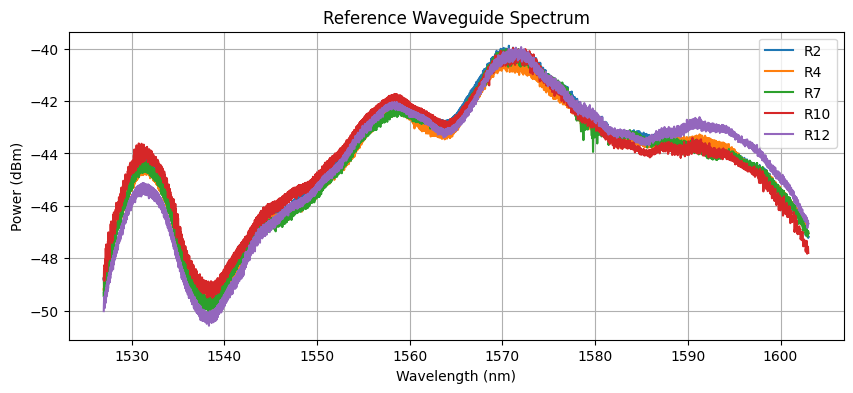

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(wavelength_wg_r2, power_wg_r2, label='R2')
plt.plot(wavelength_wg_r4, power_wg_r4, label='R4')
plt.plot(wavelength_wg_r7, power_wg_r7, label='R7')
plt.plot(wavelength_wg_r10, power_wg_r10, label='R10')
plt.plot(wavelength_wg_r12, power_wg_r12, label='R12')
plt.title("Reference Waveguide Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (dBm)")
plt.grid()
plt.legend() 
plt.show()

## U1

### Optical Spectrum

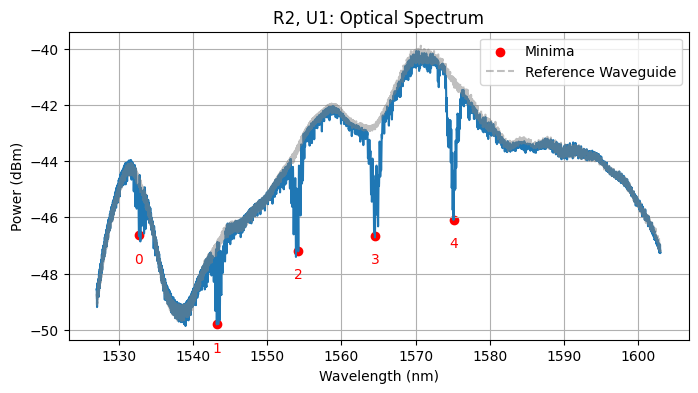

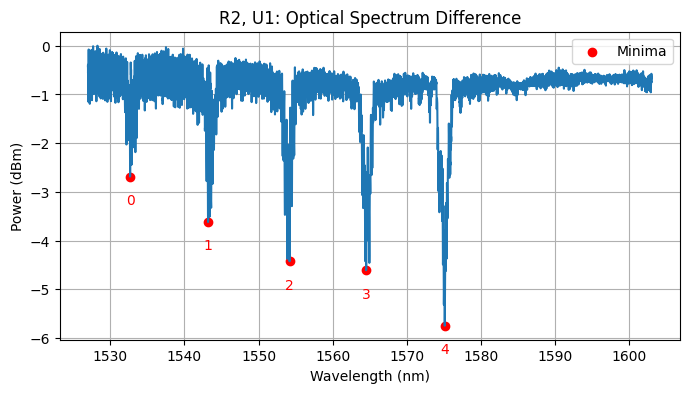

Minimums found in R2, U1 at wavelengths: [1532.684 1543.192 1554.184 1564.508 1575.108] nm


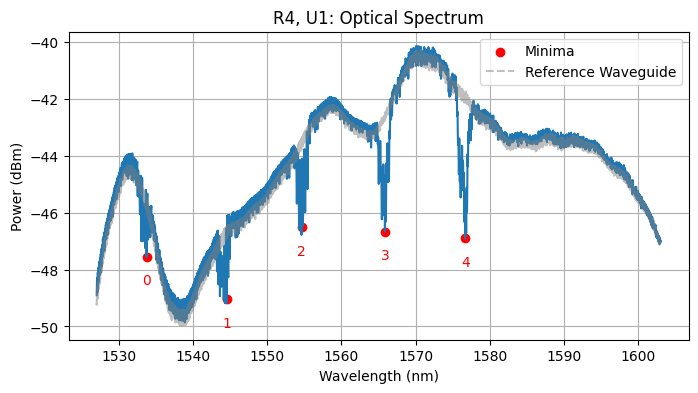

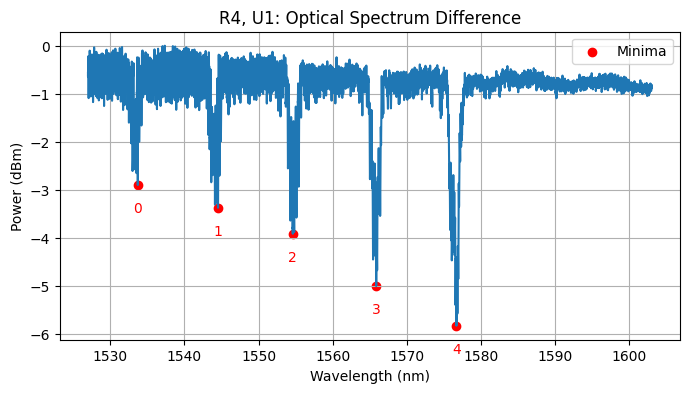

Minimums found in R4, U1 at wavelengths: [1533.72  1544.536 1554.62  1565.864 1576.684] nm


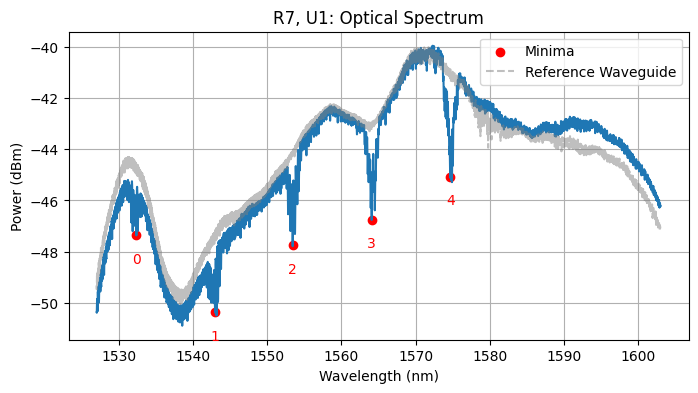

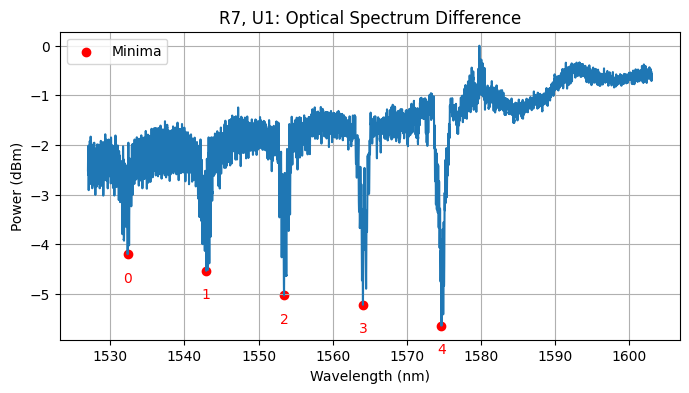

Minimums found in R7, U1 at wavelengths: [1532.352 1542.948 1553.432 1564.076 1574.664] nm


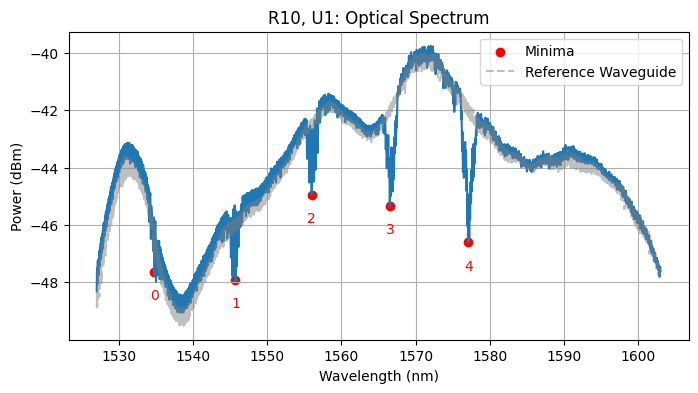

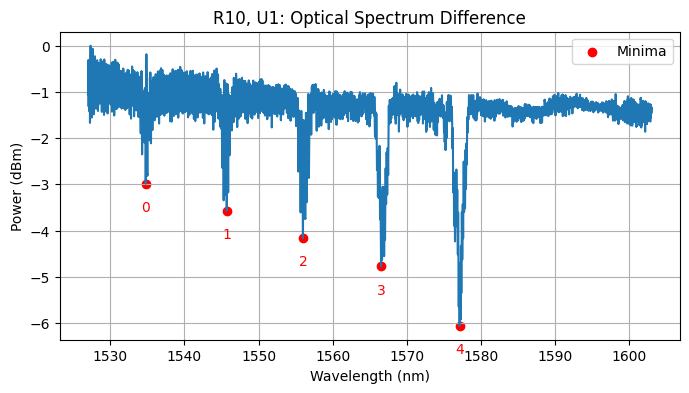

Minimums found in R10, U1 at wavelengths: [1534.784 1545.712 1555.984 1566.52  1577.108] nm


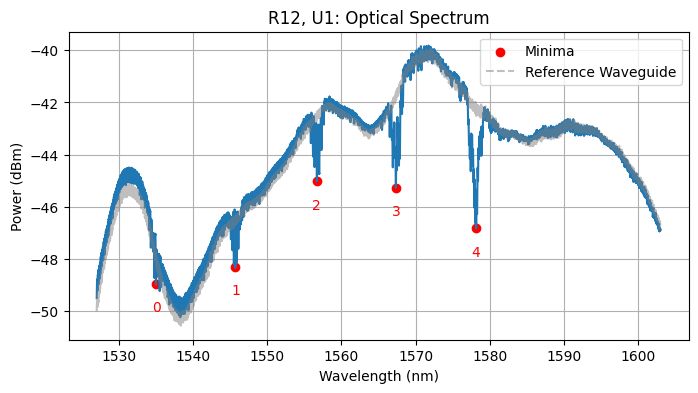

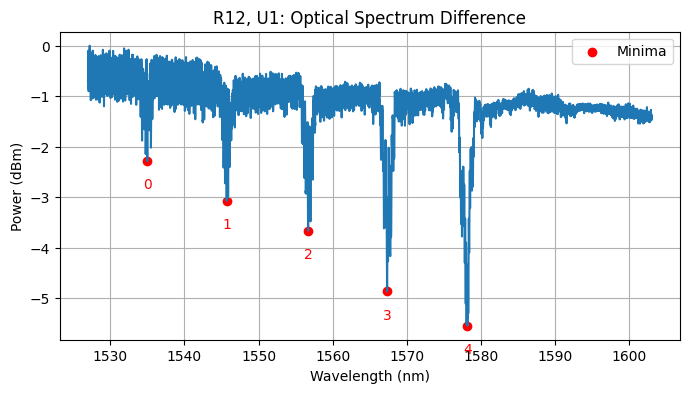

Minimums found in R12, U1 at wavelengths: [1535.    1545.7   1556.684 1567.332 1578.16 ] nm


In [35]:
# Processing parameters
threshold = 1.5     # For minima detection (dB)
separation = 10      # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u1_r2 = plot_spectra(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold, separation, "R2, U1")
wl_u1_r4 = plot_spectra(wavelength_u1_r4, power_u1_r4, power_wg_r4, threshold, separation, "R4, U1")
wl_u1_r7 = plot_spectra(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, "R7, U1")
wl_u1_r10 = plot_spectra(wavelength_u1_r10, power_u1_r10, power_wg_r10, threshold, separation, "R10, U1")
wl_u1_r12 = plot_spectra(wavelength_u1_r12, power_u1_r12, power_wg_r12, threshold, separation, "R12, U1")

### Results

In [36]:
idx = 0
fc = np.round(np.arange(1.2, 1, -0.1), 1)

#fourier_test(power_u1_r7, wavelength_u1_r7, power_wg_r7, window_size, threshold, separation, idx, fc, "U1, R7")

In [37]:
# Processing parameters
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u1 = [0.9, 0.9, 0.8, 0.8, 0.7]       # Cutoff frequency for filtering (Hz)

#plot_reflectivity_fourier(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, window_size, "U1, R7", fc_u1, threshold_fourier)

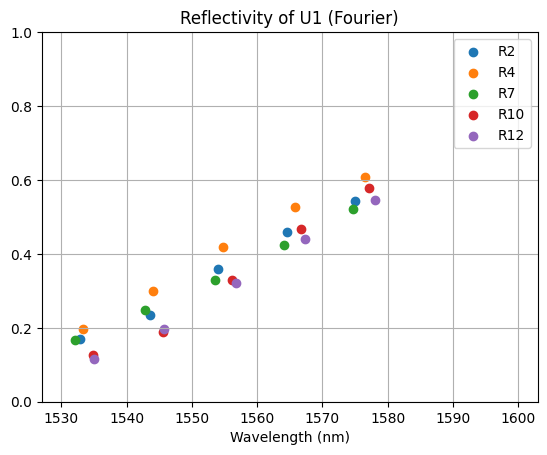

In [38]:
wl_u1_r2_fourier, R_u1_r2_fourier, BW_u1_r2_fourier = reflectivity_fourier(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r4_fourier, R_u1_r4_fourier, BW_u1_r4_fourier = reflectivity_fourier(wavelength_u1_r4, power_u1_r4, power_wg_r4, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r7_fourier, R_u1_r7_fourier, BW_u1_r7_fourier = reflectivity_fourier(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r10_fourier, R_u1_r10_fourier, BW_u1_r10_fourier = reflectivity_fourier(wavelength_u1_r10, power_u1_r10, power_wg_r10, threshold, separation, window_size, fc_u1, threshold_fourier)
wl_u1_r12_fourier, R_u1_r12_fourier, BW_u1_r12_fourier = reflectivity_fourier(wavelength_u1_r12, power_u1_r12, power_wg_r12, threshold, separation, window_size, fc_u1, threshold_fourier)

plt.scatter(wl_u1_r2_fourier, R_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, R_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, R_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, R_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, R_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U1 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

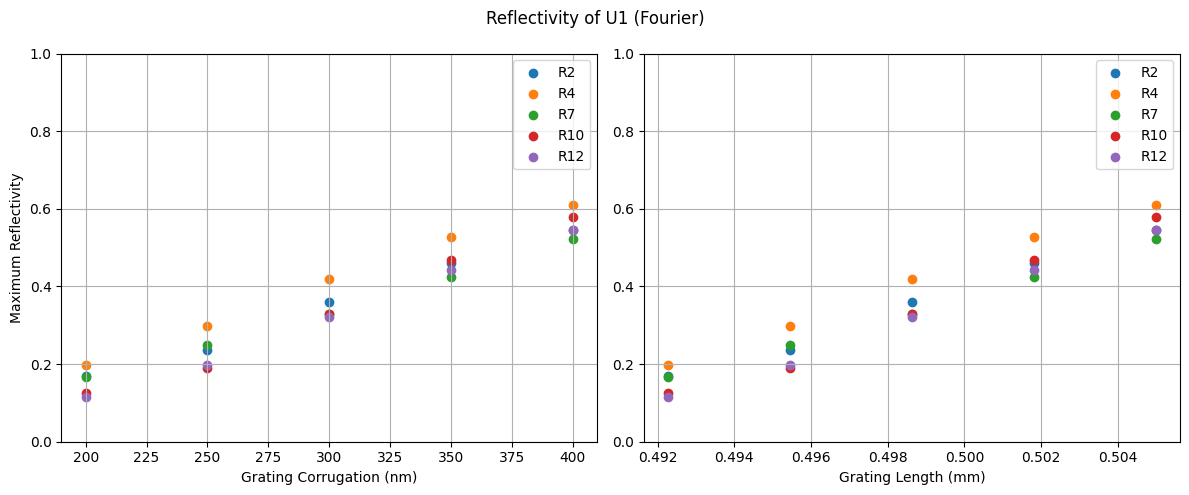

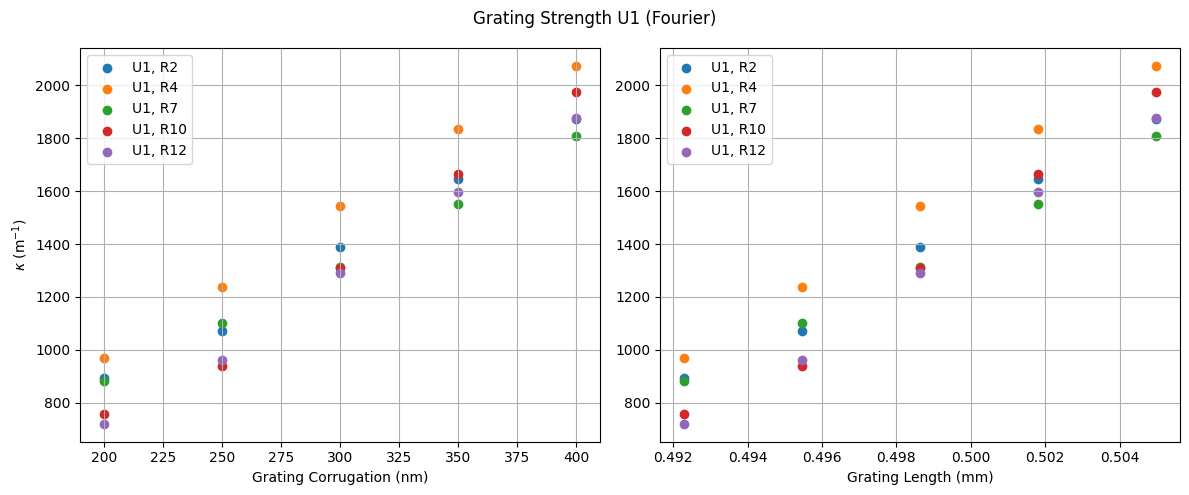

In [39]:
k_u1_r2_fourier, L_u1_r2_fourier, dW_u1_r2_fourier = grating_strength(wl_u1, wl_u1_r2_fourier, R_u1_r2_fourier, dW_u1, N_u1, n_eff)
k_u1_r4_fourier, L_u1_r4_fourier, dW_u1_r4_fourier = grating_strength(wl_u1, wl_u1_r4_fourier, R_u1_r4_fourier, dW_u1, N_u1, n_eff)
k_u1_r7_fourier, L_u1_r7_fourier, dW_u1_r7_fourier = grating_strength(wl_u1, wl_u1_r7_fourier, R_u1_r7_fourier, dW_u1, N_u1, n_eff)
k_u1_r10_fourier, L_u1_r10_fourier, dW_u1_r10_fourier = grating_strength(wl_u1, wl_u1_r10_fourier, R_u1_r10_fourier, dW_u1, N_u1, n_eff)
k_u1_r12_fourier, L_u1_r12_fourier, dW_u1_r12_fourier = grating_strength(wl_u1, wl_u1_r12_fourier, R_u1_r12_fourier, dW_u1, N_u1, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u1_r2_fourier, R_u1_r2_fourier, label = 'R2')
axs[0].scatter(dW_u1_r4_fourier, R_u1_r4_fourier, label = 'R4')
axs[0].scatter(dW_u1_r7_fourier, R_u1_r7_fourier, label = 'R7')
axs[0].scatter(dW_u1_r10_fourier, R_u1_r10_fourier, label = 'R10')
axs[0].scatter(dW_u1_r12_fourier, R_u1_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u1_r2_fourier*1e3, R_u1_r2_fourier, label = 'R2')
axs[1].scatter(L_u1_r4_fourier*1e3, R_u1_r4_fourier, label = 'R4')
axs[1].scatter(L_u1_r7_fourier*1e3, R_u1_r7_fourier, label = 'R7')
axs[1].scatter(L_u1_r10_fourier*1e3, R_u1_r10_fourier, label = 'R10')
axs[1].scatter(L_u1_r12_fourier*1e3, R_u1_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U1 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u1_r2_fourier, k_u1_r2_fourier, label = 'U1, R2')
axs[0].scatter(dW_u1_r4_fourier, k_u1_r4_fourier, label = 'U1, R4')
axs[0].scatter(dW_u1_r7_fourier, k_u1_r7_fourier, label = 'U1, R7')
axs[0].scatter(dW_u1_r10_fourier, k_u1_r10_fourier, label = 'U1, R10')
axs[0].scatter(dW_u1_r12_fourier, k_u1_r12_fourier, label = 'U1, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u1_r2_fourier*1e3, k_u1_r2_fourier, label = 'U1, R2')
axs[1].scatter(L_u1_r4_fourier*1e3, k_u1_r4_fourier, label = 'U1, R4')
axs[1].scatter(L_u1_r7_fourier*1e3, k_u1_r7_fourier, label = 'U1, R7')
axs[1].scatter(L_u1_r10_fourier*1e3, k_u1_r10_fourier, label = 'U1, R10')
axs[1].scatter(L_u1_r12_fourier*1e3, k_u1_r12_fourier, label = 'U1, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U1 (Fourier)")
plt.tight_layout()
plt.show()

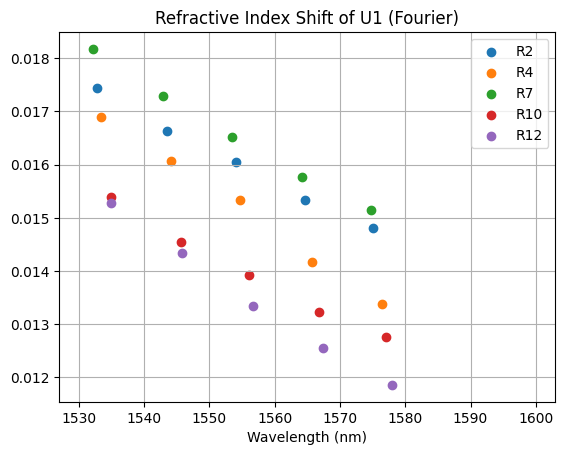

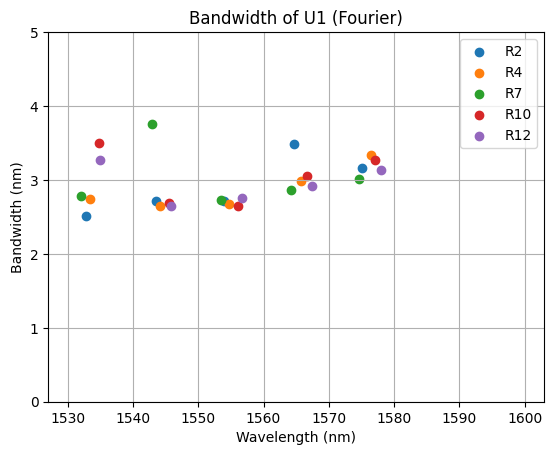

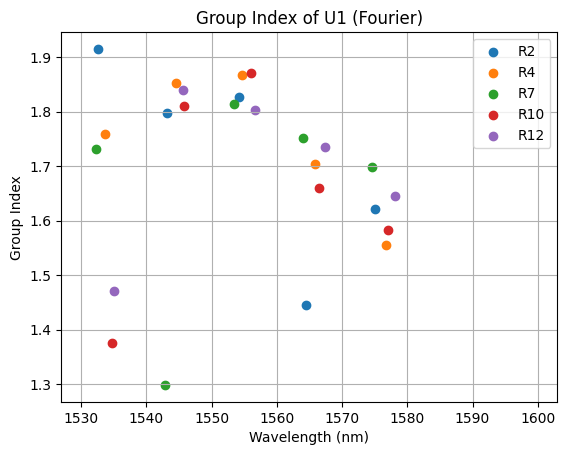

In [40]:
dwl_u1_r2_fourier, dn_u1_r2_fourier = shift_analysis(wl_u1, wl_u1_r2_fourier, n_eff)
dwl_u1_r4_fourier, dn_u1_r4_fourier = shift_analysis(wl_u1, wl_u1_r4_fourier, n_eff)
dwl_u1_r7_fourier, dn_u1_r7_fourier = shift_analysis(wl_u1, wl_u1_r7_fourier, n_eff)
dwl_u1_r10_fourier, dn_u1_r10_fourier = shift_analysis(wl_u1, wl_u1_r10_fourier, n_eff)
dwl_u1_r12_fourier, dn_u1_r12_fourier = shift_analysis(wl_u1, wl_u1_r12_fourier, n_eff)

plt.scatter(wl_u1_r2_fourier, dn_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, dn_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, dn_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, dn_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, dn_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Refractive Index Shift of U1 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()   
plt.show()

plt.scatter(wl_u1_r2_fourier, BW_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, BW_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, BW_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, BW_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, BW_u1_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U1 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 5)
plt.grid()
plt.legend()
plt.show()

ng_u1_r2 = group_index(wl_u1_r2, BW_u1_r2_fourier, k_u1_r2_fourier, L_u1_r2_fourier)
ng_u1_r4 = group_index(wl_u1_r4, BW_u1_r4_fourier, k_u1_r4_fourier, L_u1_r4_fourier)
ng_u1_r7 = group_index(wl_u1_r7, BW_u1_r7_fourier, k_u1_r7_fourier, L_u1_r7_fourier)
ng_u1_r10 = group_index(wl_u1_r10, BW_u1_r10_fourier, k_u1_r10_fourier, L_u1_r10_fourier)
ng_u1_r12 = group_index(wl_u1_r12, BW_u1_r12_fourier, k_u1_r12_fourier, L_u1_r12_fourier)    

plt.scatter(wl_u1_r2, ng_u1_r2, label='R2')
plt.scatter(wl_u1_r4, ng_u1_r4, label='R4')
plt.scatter(wl_u1_r7, ng_u1_r7, label='R7')
plt.scatter(wl_u1_r10, ng_u1_r10, label='R10')
plt.scatter(wl_u1_r12, ng_u1_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U1 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## U2

### Optical Spectrum

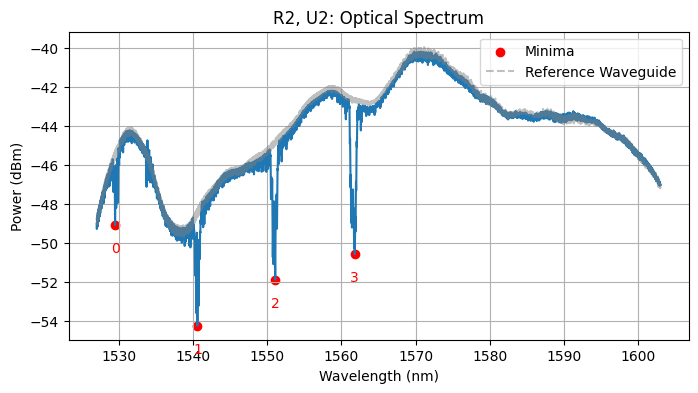

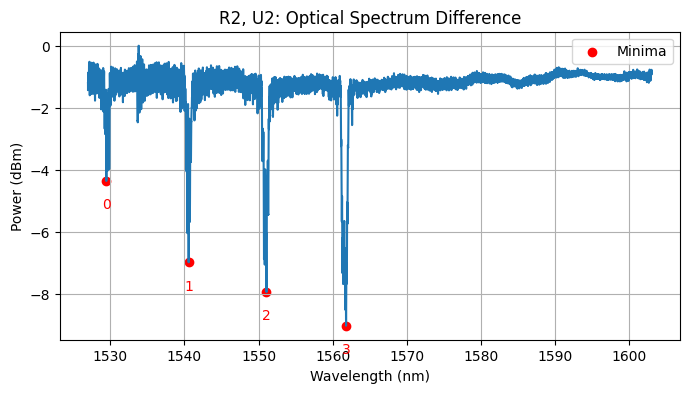

Minimums found in R2, U2 at wavelengths: [1529.476 1540.576 1551.064 1561.8  ] nm


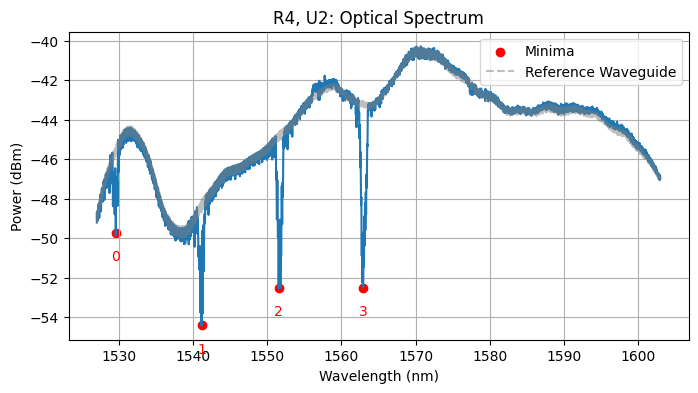

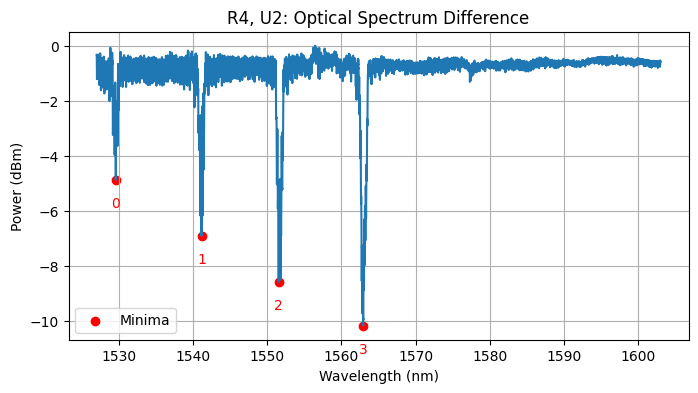

Minimums found in R4, U2 at wavelengths: [1529.576 1541.132 1551.536 1562.92 ] nm


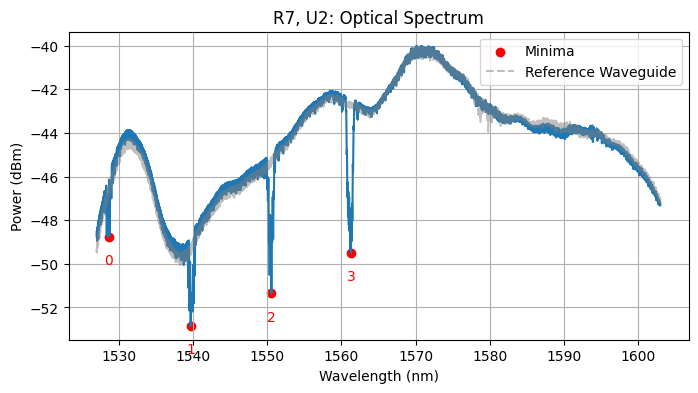

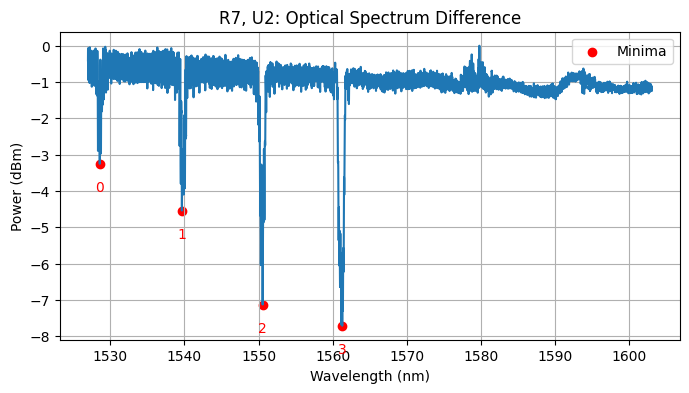

Minimums found in R7, U2 at wavelengths: [1528.592 1539.664 1550.552 1561.284] nm


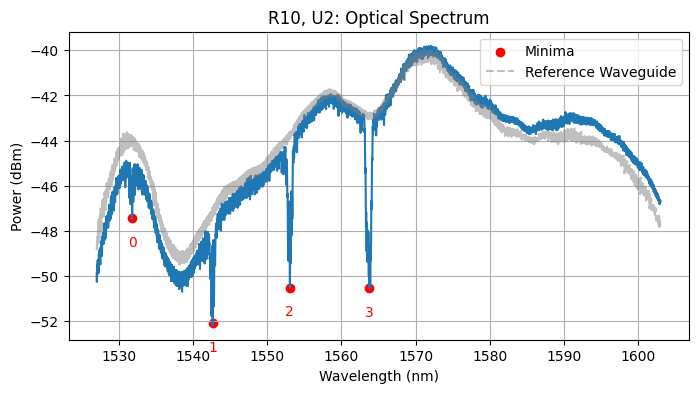

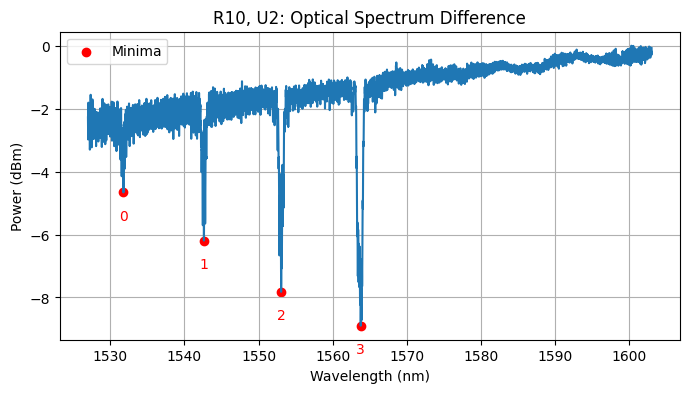

Minimums found in R10, U2 at wavelengths: [1531.784 1542.632 1553.044 1563.776] nm


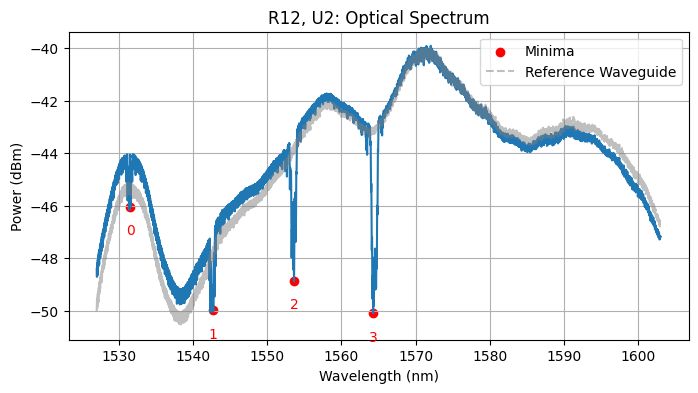

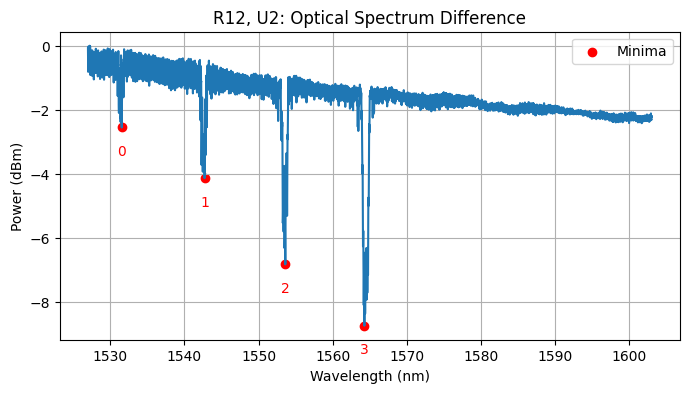

Minimums found in R12, U2 at wavelengths: [1531.548 1542.724 1553.608 1564.268] nm


In [41]:
# Processing parameters
threshold = 2       # For minima detection (dB)
separation = 10     # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u2_r2 = plot_spectra(wavelength_u2_r2, power_u2_r2, power_wg_r2, threshold, separation, "R2, U2")
wl_u2_r4 = plot_spectra(wavelength_u2_r4, power_u2_r4, power_wg_r4, threshold, separation, "R4, U2")
wl_u2_r7 = plot_spectra(wavelength_u2_r7, power_u2_r7, power_wg_r7, threshold, separation, "R7, U2")
wl_u2_r10 = plot_spectra(wavelength_u2_r10, power_u2_r10, power_wg_r10, threshold, separation, "R10, U2")
wl_u2_r12 = plot_spectra(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, "R12, U2")

### Results

In [42]:
idx = 3
fc = np.round(np.arange(3.5, 2.5, -0.1), 1)

#fourier_test(power_u2_r2, wavelength_u2_r2, power_wg_r2, window_size, threshold, separation, idx, fc, "U2, R2")

In [43]:
# Processing parameters
threshold = 2
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u2 = [1.6, 1.6, 1.5, 1.5]       # Cutoff frequency for filtering (Hz)

#plot_reflectivity_fourier(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, window_size, "U2, R12", fc_u2, threshold_fourier)

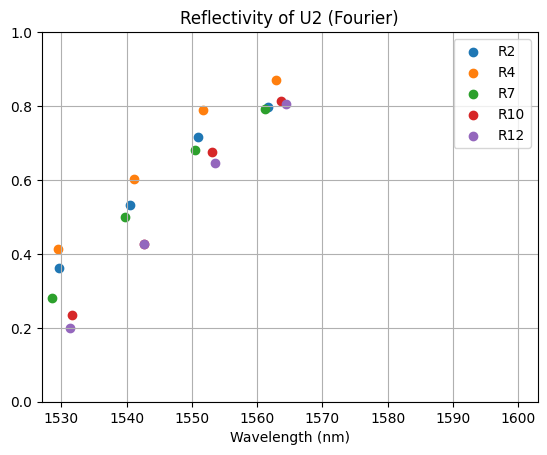

In [44]:
wl_u2_r2_fourier, R_u2_r2_fourier, BW_u2_r2_fourier = reflectivity_fourier(wavelength_u2_r2, power_u2_r2, power_wg_r2, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r4_fourier, R_u2_r4_fourier, BW_u2_r4_fourier = reflectivity_fourier(wavelength_u2_r4, power_u2_r4, power_wg_r4, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r7_fourier, R_u2_r7_fourier, BW_u2_r7_fourier = reflectivity_fourier(wavelength_u2_r7, power_u2_r7, power_wg_r7, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r10_fourier, R_u2_r10_fourier, BW_u2_r10_fourier = reflectivity_fourier(wavelength_u2_r10, power_u2_r10, power_wg_r10, threshold, separation, window_size, fc_u2, threshold_fourier)
wl_u2_r12_fourier, R_u2_r12_fourier, BW_u2_r12_fourier = reflectivity_fourier(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold, separation, window_size, fc_u2, threshold_fourier)

plt.scatter(wl_u2_r2_fourier, R_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, R_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, R_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, R_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, R_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U2 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

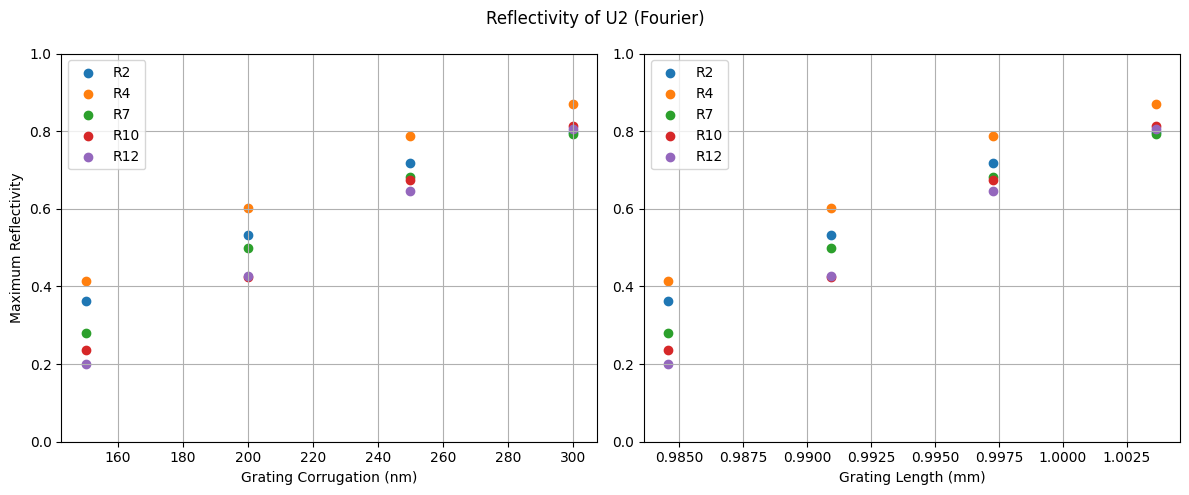

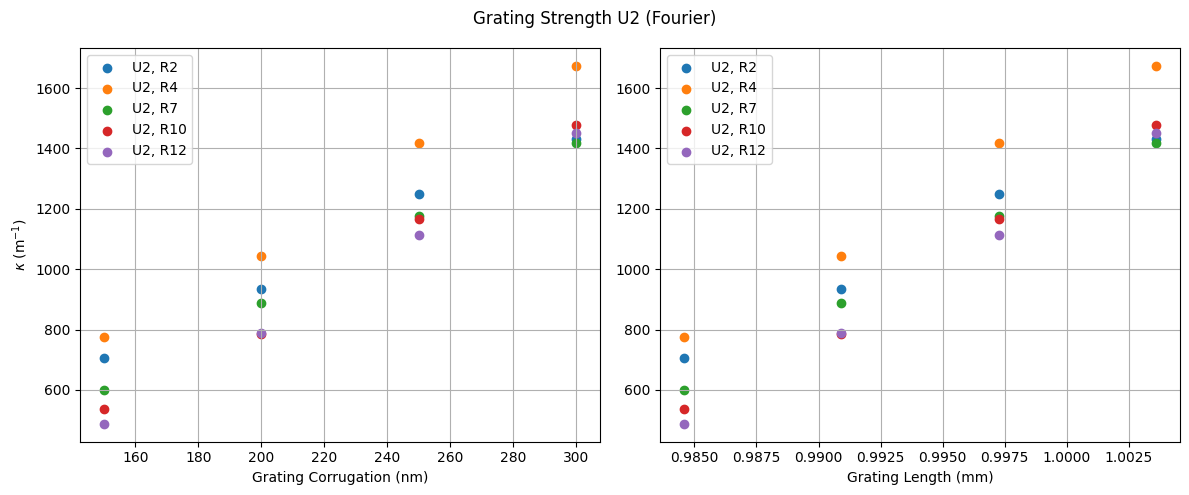

In [45]:
k_u2_r2_fourier, L_u2_r2_fourier, dW_u2_r2_fourier = grating_strength(wl_u2, wl_u2_r2_fourier, R_u2_r2_fourier, dW_u2, N_u2, n_eff)
k_u2_r4_fourier, L_u2_r4_fourier, dW_u2_r4_fourier = grating_strength(wl_u2, wl_u2_r4_fourier, R_u2_r4_fourier, dW_u2, N_u2, n_eff)
k_u2_r7_fourier, L_u2_r7_fourier, dW_u2_r7_fourier = grating_strength(wl_u2, wl_u2_r7_fourier, R_u2_r7_fourier, dW_u2, N_u2, n_eff)
k_u2_r10_fourier, L_u2_r10_fourier, dW_u2_r10_fourier = grating_strength(wl_u2, wl_u2_r10_fourier, R_u2_r10_fourier, dW_u2, N_u2, n_eff)
k_u2_r12_fourier, L_u2_r12_fourier, dW_u2_r12_fourier = grating_strength(wl_u2, wl_u2_r12_fourier, R_u2_r12_fourier, dW_u2, N_u2, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u2_r2_fourier, R_u2_r2_fourier, label = 'R2')
axs[0].scatter(dW_u2_r4_fourier, R_u2_r4_fourier, label = 'R4')
axs[0].scatter(dW_u2_r7_fourier, R_u2_r7_fourier, label = 'R7')
axs[0].scatter(dW_u2_r10_fourier, R_u2_r10_fourier, label = 'R10')
axs[0].scatter(dW_u2_r12_fourier, R_u2_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u2_r2_fourier*1e3, R_u2_r2_fourier, label = 'R2')
axs[1].scatter(L_u2_r4_fourier*1e3, R_u2_r4_fourier, label = 'R4')
axs[1].scatter(L_u2_r7_fourier*1e3, R_u2_r7_fourier, label = 'R7')
axs[1].scatter(L_u2_r10_fourier*1e3, R_u2_r10_fourier, label = 'R10')
axs[1].scatter(L_u2_r12_fourier*1e3, R_u2_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U2 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u2_r2_fourier, k_u2_r2_fourier, label = 'U2, R2')
axs[0].scatter(dW_u2_r4_fourier, k_u2_r4_fourier, label = 'U2, R4')
axs[0].scatter(dW_u2_r7_fourier, k_u2_r7_fourier, label = 'U2, R7')
axs[0].scatter(dW_u2_r10_fourier, k_u2_r10_fourier, label = 'U2, R10')
axs[0].scatter(dW_u2_r12_fourier, k_u2_r12_fourier, label = 'U2, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u2_r2_fourier*1e3, k_u2_r2_fourier, label = 'U2, R2')
axs[1].scatter(L_u2_r4_fourier*1e3, k_u2_r4_fourier, label = 'U2, R4')
axs[1].scatter(L_u2_r7_fourier*1e3, k_u2_r7_fourier, label = 'U2, R7')
axs[1].scatter(L_u2_r10_fourier*1e3, k_u2_r10_fourier, label = 'U2, R10')
axs[1].scatter(L_u2_r12_fourier*1e3, k_u2_r12_fourier, label = 'U2, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U2 (Fourier)")
plt.tight_layout()
plt.show()

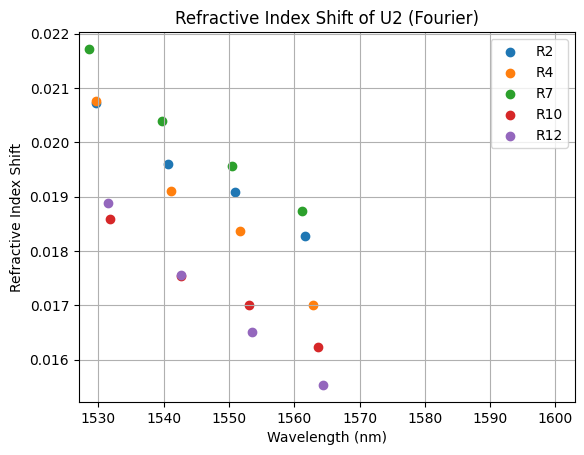

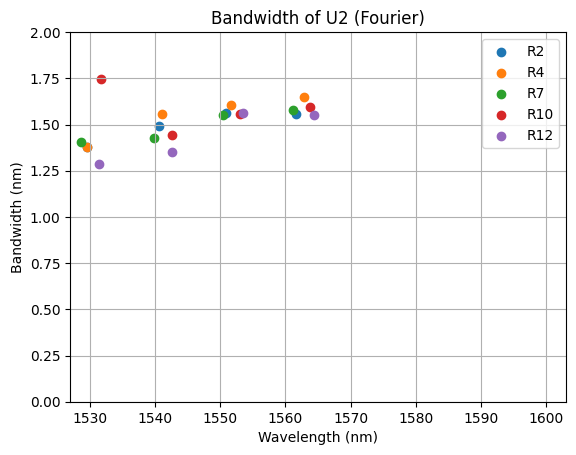

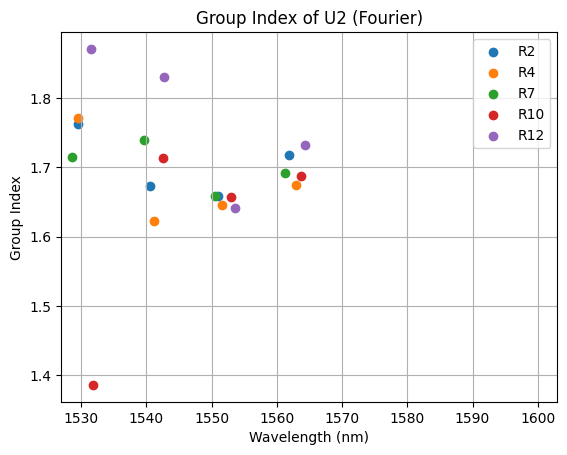

In [46]:
dwl_u2_r2_fourier, dn_u2_r2_fourier = shift_analysis(wl_u2, wl_u2_r2_fourier, n_eff)
dwl_u2_r4_fourier, dn_u2_r4_fourier = shift_analysis(wl_u2, wl_u2_r4_fourier, n_eff)
dwl_u2_r7_fourier, dn_u2_r7_fourier = shift_analysis(wl_u2, wl_u2_r7_fourier, n_eff)
dwl_u2_r10_fourier, dn_u2_r10_fourier = shift_analysis(wl_u2, wl_u2_r10_fourier, n_eff)
dwl_u2_r12_fourier, dn_u2_r12_fourier = shift_analysis(wl_u2, wl_u2_r12_fourier, n_eff)

plt.scatter(wl_u2_r2_fourier, dn_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, dn_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, dn_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, dn_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, dn_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index Shift")
plt.title("Refractive Index Shift of U2 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()  
plt.show()

plt.scatter(wl_u2_r2_fourier, BW_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, BW_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, BW_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, BW_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, BW_u2_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U2 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()

ng_u2_r2 = group_index(wl_u2_r2, BW_u2_r2_fourier, k_u2_r2_fourier, L_u2_r2_fourier)
ng_u2_r4 = group_index(wl_u2_r4, BW_u2_r4_fourier, k_u2_r4_fourier, L_u2_r4_fourier)
ng_u2_r7 = group_index(wl_u2_r7, BW_u2_r7_fourier, k_u2_r7_fourier, L_u2_r7_fourier)
ng_u2_r10 = group_index(wl_u2_r10, BW_u2_r10_fourier, k_u2_r10_fourier, L_u2_r10_fourier)
ng_u2_r12 = group_index(wl_u2_r12, BW_u2_r12_fourier, k_u2_r12_fourier, L_u2_r12_fourier)    

plt.scatter(wl_u2_r2, ng_u2_r2, label='R2')
plt.scatter(wl_u2_r4, ng_u2_r4, label='R4')
plt.scatter(wl_u2_r7, ng_u2_r7, label='R7')
plt.scatter(wl_u2_r10, ng_u2_r10, label='R10')
plt.scatter(wl_u2_r12, ng_u2_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U2 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## U3

### Optical Spectrum

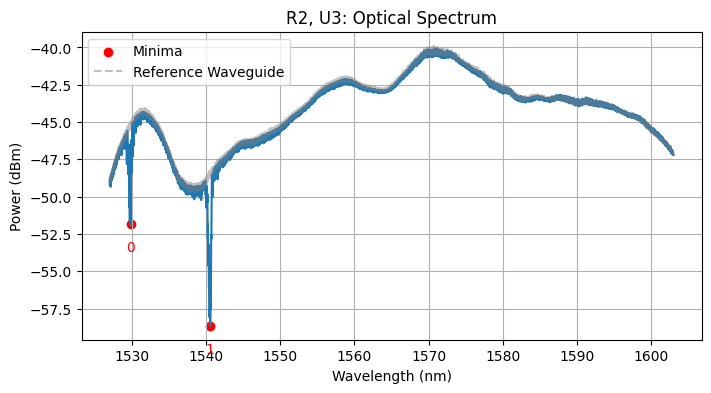

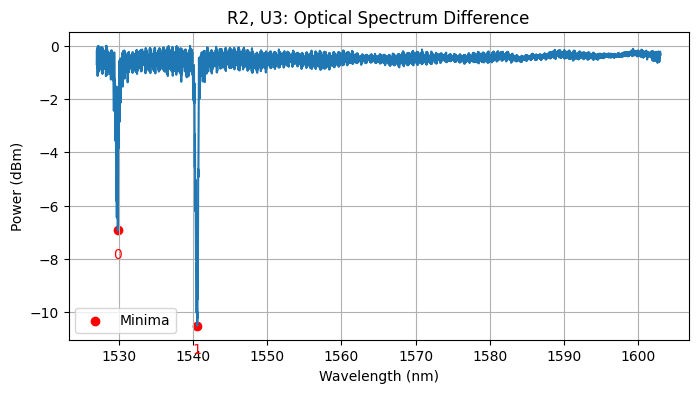

Minimums found in R2, U3 at wavelengths: [1529.844 1540.56 ] nm


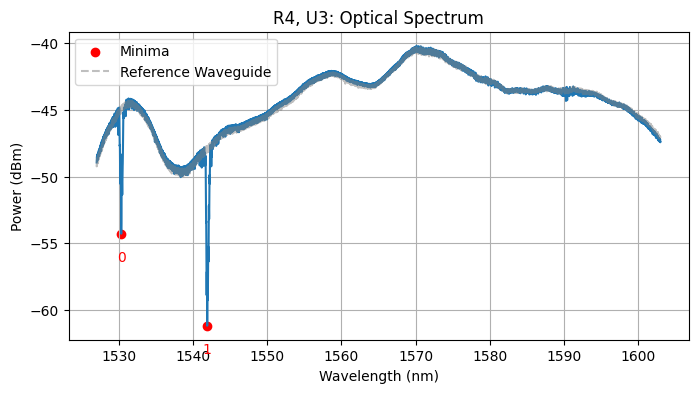

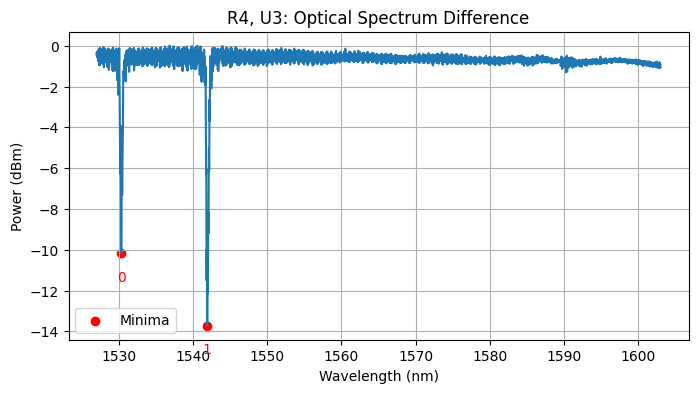

Minimums found in R4, U3 at wavelengths: [1530.304 1541.9  ] nm


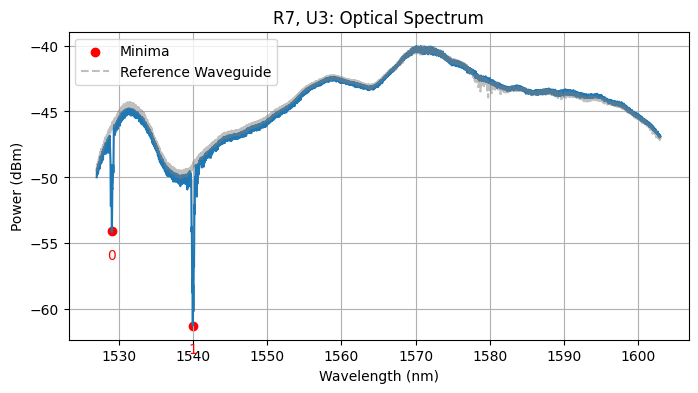

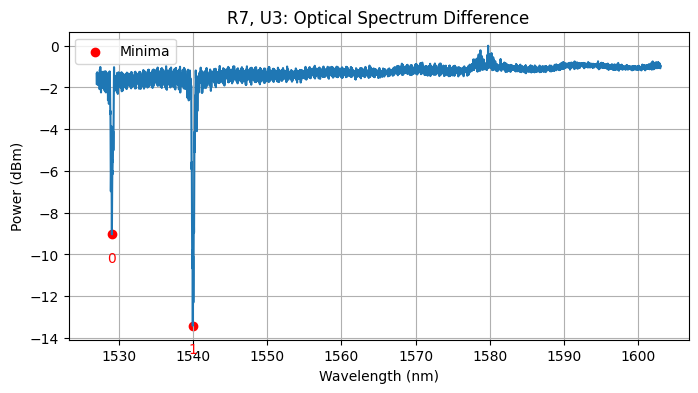

Minimums found in R7, U3 at wavelengths: [1529.048 1539.952] nm


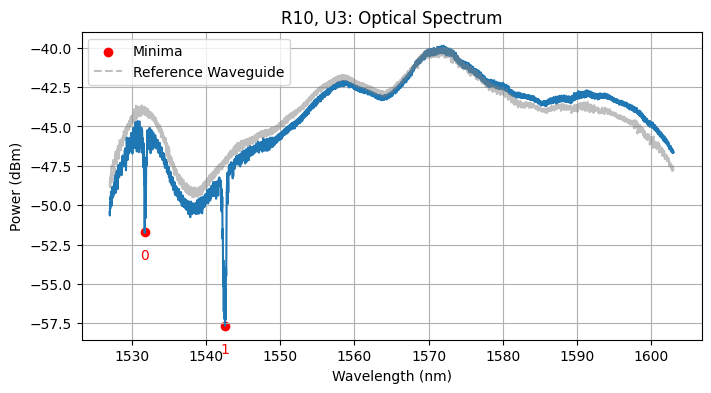

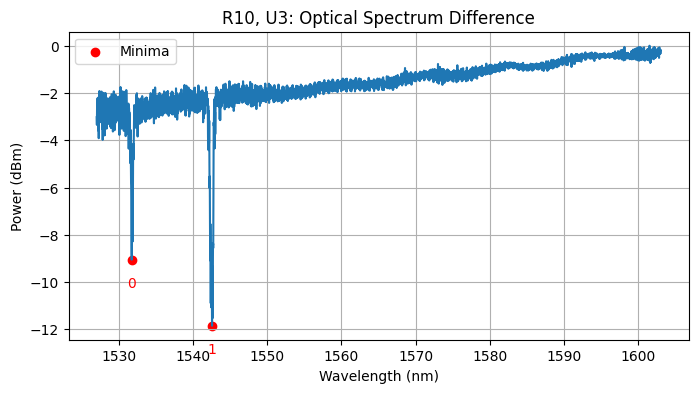

Minimums found in R10, U3 at wavelengths: [1531.72  1542.548] nm


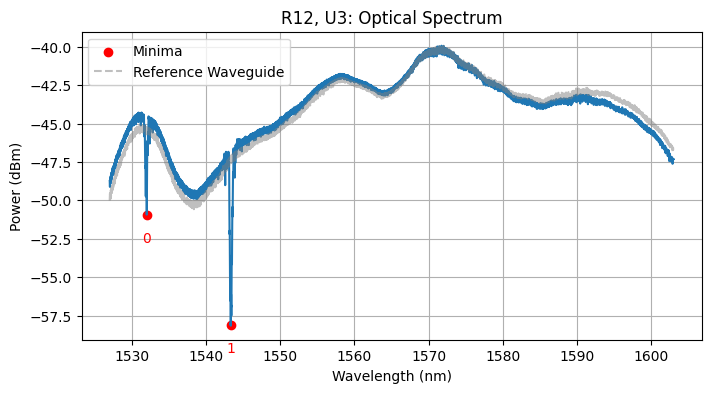

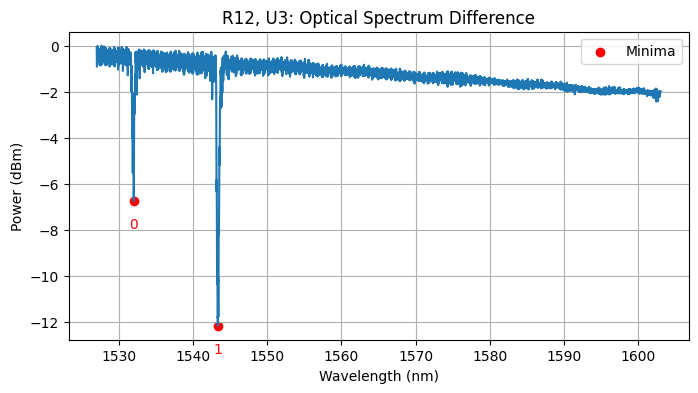

Minimums found in R12, U3 at wavelengths: [1532.    1543.332] nm


In [47]:
# Processing parameters
threshold = 2       # For minima detection (dB)
separation = 10     # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

wl_u3_r2 = plot_spectra(wavelength_u3_r2, power_u3_r2, power_wg_r2, threshold, separation, "R2, U3")
wl_u3_r4 = plot_spectra(wavelength_u3_r4, power_u3_r4, power_wg_r4, threshold, separation, "R4, U3")
wl_u3_r7 = plot_spectra(wavelength_u3_r7, power_u3_r7, power_wg_r7, threshold, separation, "R7, U3")
wl_u3_r10 = plot_spectra(wavelength_u3_r10, power_u3_r10, power_wg_r10, threshold, separation, "R10, U3")
wl_u3_r12 = plot_spectra(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, "R12, U3")

### Results

In [48]:
idx = 1
fc = np.round(np.arange(3, 1, -0.1), 1)

#fourier_test(power_u3_r4, wavelength_u3_r4, power_wg_r4, window_size, threshold, separation, idx, fc, "U3, R4")

In [49]:
# Processing parameters
threshold_fourier = 0.0            # For minima detection in Fourier Transform (dB)
fc_u3 = [2, 1.7]                   # Cutoff frequency for filtering (Hz)
fc_u3_r4 = [2, 1.6]                     

#plot_reflectivity_fourier(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, window_size, "U3, R12", fc_u3, threshold_fourier)

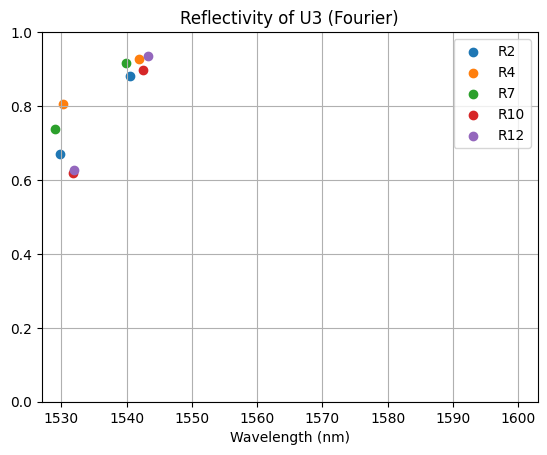

In [50]:
wl_u3_r2_fourier, R_u3_r2_fourier, BW_u3_r2_fourier = reflectivity_fourier(wavelength_u3_r2, power_u3_r2, power_wg_r2, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r4_fourier, R_u3_r4_fourier, BW_u3_r4_fourier = reflectivity_fourier(wavelength_u3_r4, power_u3_r4, power_wg_r4, threshold, separation, window_size, fc_u3_r4, threshold_fourier)
wl_u3_r7_fourier, R_u3_r7_fourier, BW_u3_r7_fourier = reflectivity_fourier(wavelength_u3_r7, power_u3_r7, power_wg_r7, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r10_fourier, R_u3_r10_fourier, BW_u3_r10_fourier = reflectivity_fourier(wavelength_u3_r10, power_u3_r10, power_wg_r10, threshold, separation, window_size, fc_u3, threshold_fourier)
wl_u3_r12_fourier, R_u3_r12_fourier, BW_u3_r12_fourier = reflectivity_fourier(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold, separation, window_size, fc_u3, threshold_fourier)

plt.scatter(wl_u3_r2_fourier, R_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, R_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, R_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, R_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, R_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U3 (Fourier)")
plt.ylim(0, 1)
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

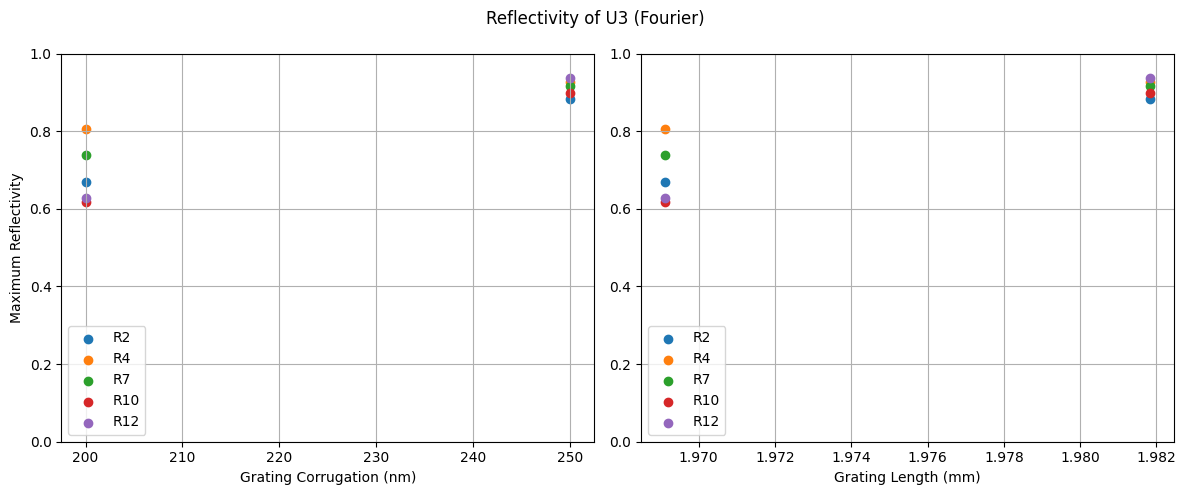

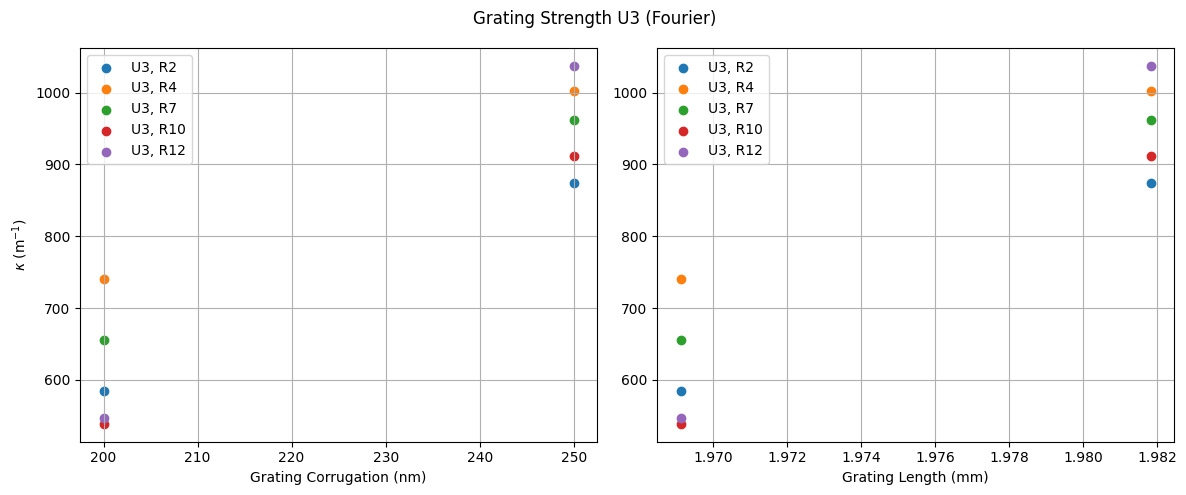

In [51]:
k_u3_r2_fourier, L_u3_r2_fourier, dW_u3_r2_fourier = grating_strength(wl_u3, wl_u3_r2_fourier, R_u3_r2_fourier, dW_u3, N_u3, n_eff)
k_u3_r4_fourier, L_u3_r4_fourier, dW_u3_r4_fourier = grating_strength(wl_u3, wl_u3_r4_fourier, R_u3_r4_fourier, dW_u3, N_u3, n_eff)
k_u3_r7_fourier, L_u3_r7_fourier, dW_u3_r7_fourier = grating_strength(wl_u3, wl_u3_r7_fourier, R_u3_r7_fourier, dW_u3, N_u3, n_eff)
k_u3_r10_fourier, L_u3_r10_fourier, dW_u3_r10_fourier = grating_strength(wl_u3, wl_u3_r10_fourier, R_u3_r10_fourier, dW_u3, N_u3, n_eff)
k_u3_r12_fourier, L_u3_r12_fourier, dW_u3_r12_fourier = grating_strength(wl_u3, wl_u3_r12_fourier, R_u3_r12_fourier, dW_u3, N_u3, n_eff)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u3_r2_fourier, R_u3_r2_fourier, label = 'R2')
axs[0].scatter(dW_u3_r4_fourier, R_u3_r4_fourier, label = 'R4')
axs[0].scatter(dW_u3_r7_fourier, R_u3_r7_fourier, label = 'R7')
axs[0].scatter(dW_u3_r10_fourier, R_u3_r10_fourier, label = 'R10')
axs[0].scatter(dW_u3_r12_fourier, R_u3_r12_fourier, label = 'R12')

axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel("Maximum Reflectivity")
axs[0].set_ylim(0, 1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u3_r2_fourier*1e3, R_u3_r2_fourier, label = 'R2')
axs[1].scatter(L_u3_r4_fourier*1e3, R_u3_r4_fourier, label = 'R4')
axs[1].scatter(L_u3_r7_fourier*1e3, R_u3_r7_fourier, label = 'R7')
axs[1].scatter(L_u3_r10_fourier*1e3, R_u3_r10_fourier, label = 'R10')
axs[1].scatter(L_u3_r12_fourier*1e3, R_u3_r12_fourier, label = 'R12')

axs[1].set_xlabel("Grating Length (mm)")
axs[1].set_ylim(0, 1)
axs[1].grid()
axs[1].legend() 

plt.suptitle('Reflectivity of U3 (Fourier)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(dW_u3_r2_fourier, k_u3_r2_fourier, label = 'U3, R2')
axs[0].scatter(dW_u3_r4_fourier, k_u3_r4_fourier, label = 'U3, R4')
axs[0].scatter(dW_u3_r7_fourier, k_u3_r7_fourier, label = 'U3, R7')
axs[0].scatter(dW_u3_r10_fourier, k_u3_r10_fourier, label = 'U3, R10')
axs[0].scatter(dW_u3_r12_fourier, k_u3_r12_fourier, label = 'U3, R12')
axs[0].set_xlabel("Grating Corrugation (nm)")
axs[0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[0].grid()
axs[0].legend()   

axs[1].scatter(L_u3_r2_fourier*1e3, k_u3_r2_fourier, label = 'U3, R2')
axs[1].scatter(L_u3_r4_fourier*1e3, k_u3_r4_fourier, label = 'U3, R4')
axs[1].scatter(L_u3_r7_fourier*1e3, k_u3_r7_fourier, label = 'U3, R7')
axs[1].scatter(L_u3_r10_fourier*1e3, k_u3_r10_fourier, label = 'U3, R10')
axs[1].scatter(L_u3_r12_fourier*1e3, k_u3_r12_fourier, label = 'U3, R12')
axs[1].set_xlabel("Grating Length (mm)")
axs[1].grid()
axs[1].legend()   

plt.suptitle("Grating Strength U3 (Fourier)")
plt.tight_layout()
plt.show()

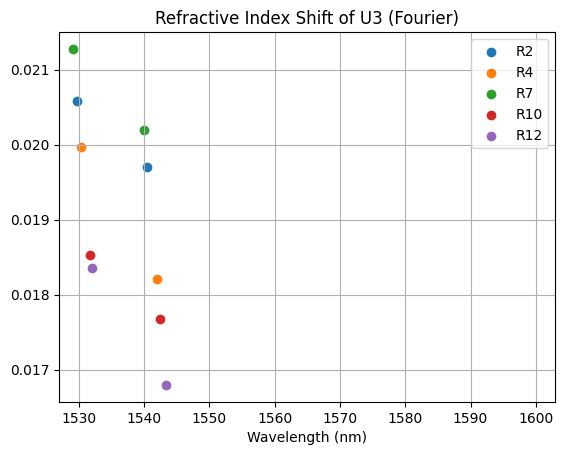

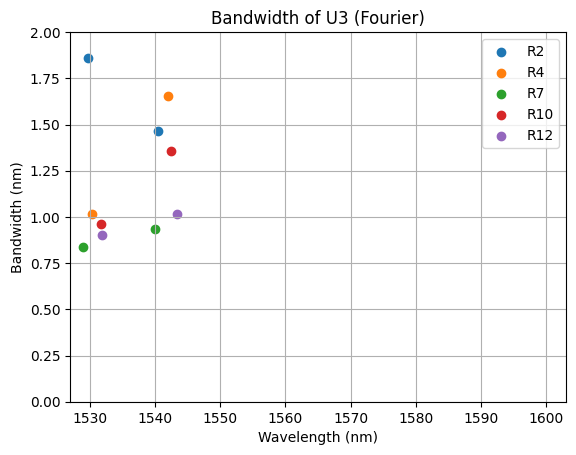

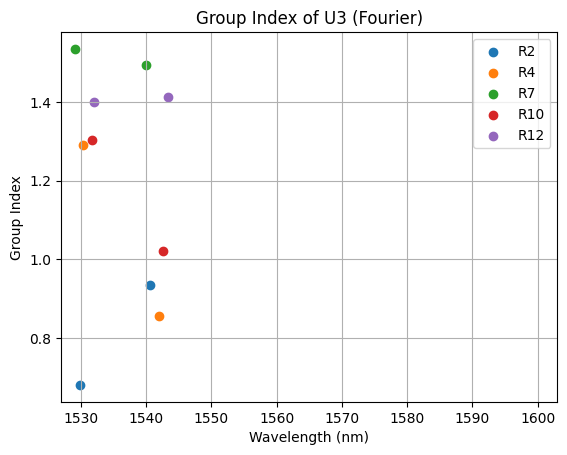

In [52]:
dwl_u3_r2_fourier, dn_u3_r2_fourier = shift_analysis(wl_u3, wl_u3_r2_fourier, n_eff)
dwl_u3_r4_fourier, dn_u3_r4_fourier = shift_analysis(wl_u3, wl_u3_r4_fourier, n_eff)
dwl_u3_r7_fourier, dn_u3_r7_fourier = shift_analysis(wl_u3, wl_u3_r7_fourier, n_eff)
dwl_u3_r10_fourier, dn_u3_r10_fourier = shift_analysis(wl_u3, wl_u3_r10_fourier, n_eff)
dwl_u3_r12_fourier, dn_u3_r12_fourier = shift_analysis(wl_u3, wl_u3_r12_fourier, n_eff)

plt.scatter(wl_u3_r2_fourier, dn_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, dn_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, dn_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, dn_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, dn_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.title("Refractive Index Shift of U3 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()   
plt.show()

plt.scatter(wl_u3_r2_fourier, BW_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, BW_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, BW_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, BW_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, BW_u3_r12_fourier, label='R12')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bandwidth (nm)")
plt.title("Bandwidth of U3 (Fourier)")
plt.xlim(wl_0, wl_1)
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()

ng_u3_r2 = group_index(wl_u3_r2, BW_u3_r2_fourier, k_u3_r2_fourier, L_u3_r2_fourier)
ng_u3_r4 = group_index(wl_u3_r4, BW_u3_r4_fourier, k_u3_r4_fourier, L_u3_r4_fourier)
ng_u3_r7 = group_index(wl_u3_r7, BW_u3_r7_fourier, k_u3_r7_fourier, L_u3_r7_fourier)
ng_u3_r10 = group_index(wl_u3_r10, BW_u3_r10_fourier, k_u3_r10_fourier, L_u3_r10_fourier)
ng_u3_r12 = group_index(wl_u3_r12, BW_u3_r12_fourier, k_u3_r12_fourier, L_u3_r12_fourier)    

plt.scatter(wl_u3_r2, ng_u3_r2, label='R2')
plt.scatter(wl_u3_r4, ng_u3_r4, label='R4')
plt.scatter(wl_u3_r7, ng_u3_r7, label='R7')
plt.scatter(wl_u3_r10, ng_u3_r10, label='R10')
plt.scatter(wl_u3_r12, ng_u3_r12, label='R12')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Group Index')
plt.title('Group Index of U3 (Fourier)')
plt.legend()
plt.grid()
plt.xlim(wl_0, wl_1)
plt.show()

## Grating Strength Fit

### Auxiliar Function

In [53]:
def reflectivity_corrugation_fourier(w):
    buff_R = []
    buff_L = []
    mean_R = []
    mean_L = []

    if w < np.min([np.min(dW_u1_r2_fourier), np.min(dW_u2_r2_fourier), np.min(dW_u3_r2_fourier)]) or w > np.max([np.max(dW_u1_r2_fourier), np.max(dW_u2_r2_fourier), np.max(dW_u3_r2_fourier)]):
        print(f'No data')
        return None

    if w<min(dW_u1_r2_fourier) or w>max(dW_u1_r2_fourier):
        print(f'No data for U1 for grating corrugation of {w} nm')

    if w<min(dW_u2_r2_fourier) or w>max(dW_u2_r2_fourier):
        print(f'No data for U2 for grating corrugation of {w} nm')

    if w<min(dW_u3_r2_fourier) or w>max(dW_u3_r2_fourier):
        print(f'No data for U3 for grating corrugation of {w} nm')
    

    for i in range(len(dW_u1_r2_fourier)):
        if dW_u1_r2_fourier[i] == w:
            buff_R.append(R_u1_r2_fourier[i]); buff_R.append(R_u1_r4_fourier[i]); buff_R.append(R_u1_r7_fourier[i]); buff_R.append(R_u1_r10_fourier[i]); buff_R.append(R_u1_r12_fourier[i])
            mean_R.append(np.mean([R_u1_r2_fourier[i], R_u1_r4_fourier[i], R_u1_r7_fourier[i], R_u1_r10_fourier[i], R_u1_r12_fourier[i]]))

            buff_L.append(L_u1_r2_fourier[i]); buff_L.append(L_u1_r4_fourier[i]); buff_L.append(L_u1_r7_fourier[i]); buff_L.append(L_u1_r10_fourier[i]); buff_L.append(L_u1_r12_fourier[i])
            mean_L.append(np.mean([L_u1_r2_fourier[i], L_u1_r4_fourier[i], L_u1_r7_fourier[i], L_u1_r10_fourier[i], L_u1_r12_fourier[i]]))

    for i in range(len(dW_u2_r2_fourier)):
        if dW_u2_r2_fourier[i] == w:
            buff_R.append(R_u2_r2_fourier[i]); buff_R.append(R_u2_r4_fourier[i]); buff_R.append(R_u2_r7_fourier[i]); buff_R.append(R_u2_r10_fourier[i]); buff_R.append(R_u2_r12_fourier[i])
            mean_R.append(np.mean([R_u2_r2_fourier[i], R_u2_r4_fourier[i], R_u2_r7_fourier[i], R_u2_r10_fourier[i], R_u2_r12_fourier[i]]))

            buff_L.append(L_u2_r2_fourier[i]); buff_L.append(L_u2_r4_fourier[i]); buff_L.append(L_u2_r7_fourier[i]); buff_L.append(L_u2_r10_fourier[i]); buff_L.append(L_u2_r12_fourier[i])
            mean_L.append(np.mean([L_u2_r2_fourier[i], L_u2_r4_fourier[i], L_u2_r7_fourier[i], L_u2_r10_fourier[i], L_u2_r12_fourier[i]]))

    for i in range(len(dW_u3_r2_fourier)):
        if dW_u3_r2_fourier[i] == w:
            buff_R.append(R_u3_r2_fourier[i]); buff_R.append(R_u3_r4_fourier[i]); buff_R.append(R_u3_r7_fourier[i]); buff_R.append(R_u3_r10_fourier[i]); buff_R.append(R_u3_r12_fourier[i])
            mean_R.append(np.mean([R_u3_r2_fourier[i], R_u3_r4_fourier[i], R_u3_r7_fourier[i], R_u3_r10_fourier[i], R_u3_r12_fourier[i]]))

            buff_L.append(L_u3_r2_fourier[i]); buff_L.append(L_u3_r4_fourier[i]); buff_L.append(L_u3_r7_fourier[i]); buff_L.append(L_u3_r10_fourier[i]); buff_L.append(L_u3_r12_fourier[i])
            mean_L.append(np.mean([L_u3_r2_fourier[i], L_u3_r4_fourier[i], L_u3_r7_fourier[i], L_u3_r10_fourier[i], L_u3_r12_fourier[i]]))

    plt.scatter(np.array(buff_L)*1e3, np.array(buff_R), label='Data')
    plt.scatter(np.array(mean_L)*1e3, np.array(mean_R), label='Mean', color='r')
    plt.title(f'Maximum Reflectivity (Fourier) for Corrugation {w} nm')

    x = np.linspace(0, 1.5*np.max(buff_L), 100)
    popt, pcov = curve_fit(reflectivity_model, mean_L, mean_R)
    plt.plot(x*1e3, reflectivity_model(x, *popt), label=r'$tanh^2(\kappa L)$', color='orange')

    plt.annotate(rf'$\kappa$={popt[0]:.2f}, Cov.={pcov[0,0]:.2f}', xy=[0.95,0.05], xycoords = 'axes fraction', ha = 'right', va = 'bottom', fontsize=11)
    plt.legend()
    plt.xlabel('Grating Length (mm)')
    plt.ylabel('Reflectivity')
    plt.grid()
    plt.show()

### Results

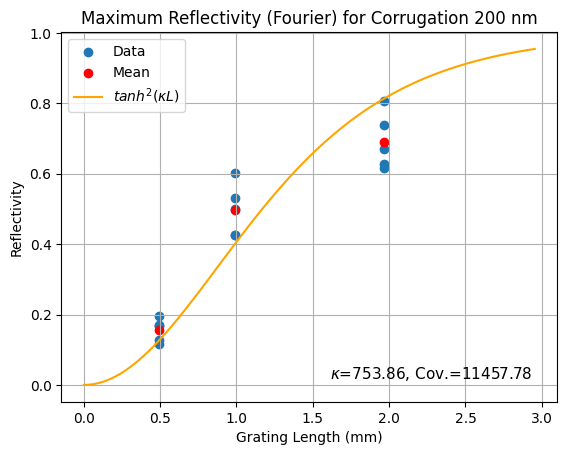

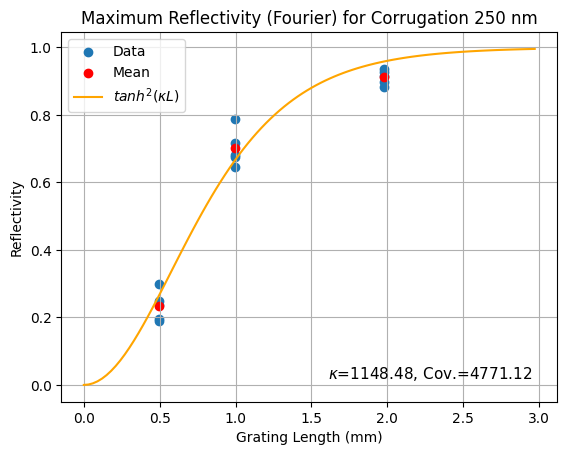

No data for U3 for grating corrugation of 300 nm


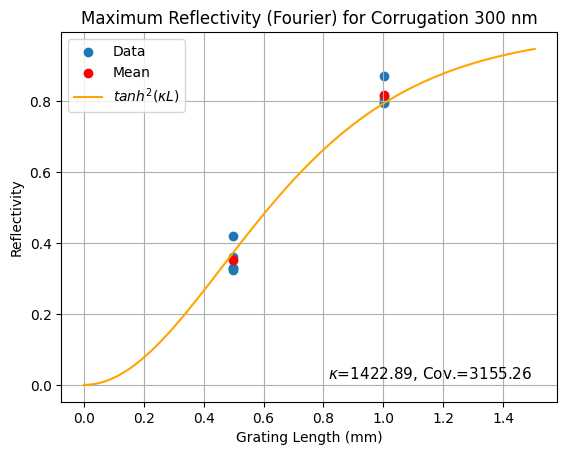

In [54]:
reflectivity_corrugation_fourier(200)
reflectivity_corrugation_fourier(250)
reflectivity_corrugation_fourier(300)